In [ ]:
# Module imports and quick usage
# These imports use the helper modules saved at `code/modules/`.
# If the modules are not found, add the repo root to sys.path (see notes).
import sys
from pathlib import Path
repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Import our helpers
try:
    from code.modules import data_utils, models, train_utils, sampling
except Exception as e:
    print('Import warning:', e)

# Example: build a tiny model and show param count
if 'models' in globals():
    m = models.build_simple_unet()
    print('Tiny model created — parameter count:', models.count_parameters(m))

# Usage: replace long inline cells by calling these helpers, e.g.
# dl = data_utils.load_image_dataset('path/to/instance_data', image_size=128, batch_size=16)
# train_utils.train_loop(m, dl, optimizer, device, epochs=1, save_path='results/checkpoint.pt')


# CA4 — Vision-Language Notebook Overview
This notebook accompanies Homework 4 and contains code for data preparation, model training, sampling, and evaluation for the Vision–Language tasks used in the assignment.

- **Purpose:** Implement and experiment with the VLM pipelines for the course assignment.
- **Structure:** Setup → Data → Model definitions → Training → Sampling / Evaluation → Plots & Metrics.
- **Run order:** Execute cells top-to-bottom. Use a GPU runtime where available.
- **Paths:** Data and artifacts are expected under the repository folders (check `instance_data`, `class_data`, and `results` directories).


## Quick Run Tips
- Run cells top-to-bottom; restart kernel if state is inconsistent.
- Use a small debug run: set `BATCH_SIZE=8`, `EPOCHS=1` to validate shapes.
- Enable mixed precision: `torch.cuda.amp.autocast()` for faster training.
- Set paths: `DATA_DIR`, `RESULTS_DIR` at the top before executing heavy cells.
- To use modules created here, ensure `code/modules` is on `sys.path` or run `pip install -e .` from project root if you convert to a package.

# Notebook Table of Contents
- Overview (run order and purpose)
- Setup & Requirements (environment + deps)
- Data (loading & preprocessing)
- Models (architectures and helpers)
- Training (loops, checkpoints, logging)
- Sampling & Inference (DDPM/DDIM, guidance)
- Evaluation & Metrics (plots, stats, distributions)
- Next Steps & Tips (smoke tests and checkpoints)


# CA4 — Vision-Language Notebook Overview
This notebook accompanies Homework 4 and contains code for data preparation, model training, sampling, and evaluation for the Vision–Language tasks used in the assignment.

- **Purpose:** Implement and experiment with the VLM pipelines for the course assignment.
- **Structure:** Setup → Data → Model definitions → Training → Sampling / Evaluation → Plots & Metrics.
- **Run order:** Execute cells top-to-bottom. Use a GPU runtime where available.
- **Paths:** Data and artifacts are expected under the repository folders (check `instance_data`, `class_data`, and `results` directories).


# Deep Generative Models - Homework 4
## Complete Implementation: Diffusion Models, Stable Diffusion, and Flow Matching

**University of Tehran - College of Engineering**

This notebook contains the complete implementation for HW4, covering:
1. **Part 1: DDPM & DDIM** - Denoising Diffusion Probabilistic Models
2. **Part 2: Stable Diffusion & DreamBooth** - Latent Diffusion with Fine-tuning
3. **Part 3: Flow Matching for Time Series** - Continuous Generative Models

---

## Prerequisites and Setup

Install required packages and import necessary libraries.

In [1]:
# Install required packages (uncomment if needed)
# !pip install torch torchvision torchaudio
# !pip install diffusers transformers accelerate
# !pip install pandas yfinance scipy
# !pip install matplotlib seaborn tqdm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math
from torchvision import transforms, datasets
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

REPORT_FIG_DIR = Path("../report/En_report/figures")
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Report figures dir: {REPORT_FIG_DIR.resolve()}")

def save_fig(filename: str, dpi: int = 200):
    """Save the current matplotlib figure into the report figures folder."""
    out_path = REPORT_FIG_DIR / filename
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"✅ Saved figure: {out_path}")

Using device: cuda
Report figures dir: /kaggle/report/En_report/figures


---
# Part 1: Diffusion Models (DDPM & DDIM)

## 1.1 Theory Background

**Forward Process (Adding Noise):**
$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t}x_{t-1}, \beta_t I)$$

**Closed Form for any timestep t:**
$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}x_0, (1-\bar{\alpha}_t)I)$$

where $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$ and $\alpha_t = 1 - \beta_t$

**Reverse Process:**
$$p_\theta(x_{t-1}|x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$

---

# Section: Data
This section loads and preprocesses datasets used in the assignment. Check `DATA_DIR` and ensure required image folders (`instance_data`, `class_data`) exist. Typical steps:
- Load images, apply transforms, and create DataLoaders.
- For flow/time-series parts, ensure CSV or price data is available and preprocessed to log-returns.
- Verify one batch shapes before training (print `x.shape`, `t.shape`).

<details>
<summary><b>Data section — show code / call helpers</b></summary>

Use `data_utils.load_image_dataset()` to replace the long image-loading cells. Example call:

```python
from code.modules.data_utils import load_image_dataset
train_dl = load_image_dataset('path/to/instance_data', image_size=128, batch_size=32)
```

Click to expand this block if you want to show or paste the original long code here.
</details>

## 1.2 Step 1: Variance Scheduler (Linear Schedule)

Implementing the noise schedule with $\beta$ linearly increasing from $\beta_{start}$ to $\beta_{end}$.

## Setup & Requirements
Before running the notebook ensure the following:
- Python 3.9+ (conda/venv recommended).
- Install dependencies: `pip install -r ../../requirements.txt` (or the project `requirements.txt`).
- GPU recommended (CUDA + cuDNN).
- Set `DATA_DIR`, `RESULTS_DIR`, and checkpoint paths at the start of the notebook if needed.
- If large models are used, lower batch sizes or use mixed precision (`torch.cuda.amp`).


In [ ]:
class DDPMScheduler:
    """
    DDPM Variance Scheduler with Linear Schedule

    Implements the forward diffusion process and provides utilities
    for the reverse process.
    """
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device='cuda'):
        self.num_timesteps = num_timesteps
        self.device = device

        # ============================================
        # Step 1: Linear Variance Schedule
        # β_t increases linearly from β_start to β_end
        # ============================================
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        self.posterior_variance = self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        self.posterior_mean_coef2 = (1.0 - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1.0 - self.alphas_cumprod)

    def _extract(self, a, t, x_shape):
        """
        Extract values from a 1D tensor for a batch of indices.

        Args:
            a: 1D tensor of values
            t: 1D tensor of indices (batch of timesteps)
            x_shape: shape of x for broadcasting

        Returns:
            Values extracted and reshaped for broadcasting
        """
        batch_size = t.shape[0]
        out = a.gather(-1, t)
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

    def perturb_input(self, x_0, t, noise=None):
        """
        Step 2: Forward Process (Perturb Input)

        Adds noise to x_0 to get x_t using the reparameterization trick:
        x_t = √(ᾱ_t) * x_0 + √(1 - ᾱ_t) * ε

        Args:
            x_0: Original clean images [B, C, H, W]
            t: Timesteps [B]
            noise: Optional pre-sampled noise

        Returns:
            x_t: Noisy images at timestep t
            noise: The noise that was added
        """
        if noise is None:
            noise = torch.randn_like(x_0, device=self.device)
        sqrt_alpha_cumprod_t = self._extract(self.sqrt_alphas_cumprod, t, x_0.shape)
        sqrt_one_minus_alpha_cumprod_t = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)
        x_t = sqrt_alpha_cumprod_t * x_0 + sqrt_one_minus_alpha_cumprod_t * noise

        return x_t, noise

    def get_posterior_mean_variance(self, x_0, x_t, t):
        """
        Compute the mean and variance of the diffusion posterior q(x_{t-1} | x_t, x_0)
        """
        posterior_mean = (
            self._extract(self.posterior_mean_coef1, t, x_t.shape) * x_0 +
            self._extract(self.posterior_mean_coef2, t, x_t.shape) * x_t
        )
        posterior_variance = self._extract(self.posterior_variance, t, x_t.shape)
        return posterior_mean, posterior_variance



### Training Notes
This cell starts the training routines. Key points:
- Inputs: batched images/latents, time indices, and optional conditioning tokens.
- Outputs: model checkpoints saved to `RESULTS_DIR` or `checkpoints/`.
- Hyperparameters to change: learning rate, batch size, epochs (`HYPERPARAMS` section near the top).
- Advice: run a short debug epoch (small subset of data) before full training to validate shapes and I/O.
- Logging: ensure `wandb` or simple `tensorboard` logging is configured if needed.


In [7]:
scheduler = DDPMScheduler(num_timesteps=1000, device=device)

✅ Saved figure: ../report/En_report/figures/ddpm_scheduler_params.png


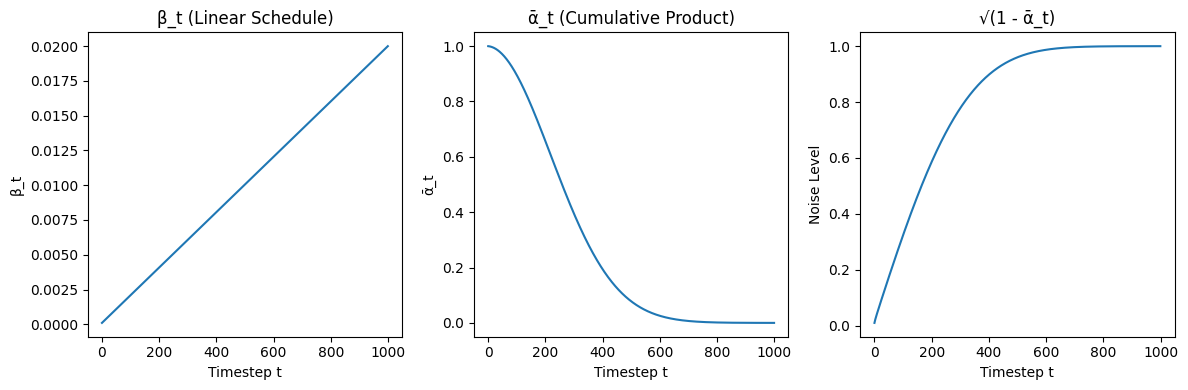

In [8]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(scheduler.betas.cpu().numpy())
plt.title('β_t (Linear Schedule)')
plt.xlabel('Timestep t')
plt.ylabel('β_t')

plt.subplot(1, 3, 2)
plt.plot(scheduler.alphas_cumprod.cpu().numpy())
plt.title('ᾱ_t (Cumulative Product)')
plt.xlabel('Timestep t')
plt.ylabel('ᾱ_t')

plt.subplot(1, 3, 3)
plt.plot(scheduler.sqrt_one_minus_alphas_cumprod.cpu().numpy())
plt.title('√(1 - ᾱ_t)')
plt.xlabel('Timestep t')
plt.ylabel('Noise Level')

plt.tight_layout()
save_fig("ddpm_scheduler_params.png")
plt.show()

## 1.3 Visualize Forward Diffusion Process

Demonstrating how noise is progressively added to an image.

# Section: Models
This area defines model architectures, schedulers, and helper utilities (U-Net, VAE, LoRA modules). Notes:
- Keep model classes in a separate module if reusing across notebooks.
- Save model summaries (`print(model)`) and parameter counts near here.
- Use `torchsummary` or `torchinfo` for layer shapes on a dummy input.

<details>
<summary><b>Models section — show code / call helpers</b></summary>

Use `models.build_simple_unet()` (or your full model builder) instead of long inline class definitions:

```python
from code.modules.models import build_simple_unet, count_parameters
model = build_simple_unet()
print('params:', count_parameters(model))
```

Paste original model class here if you need it visible for editing.
</details>

✅ Saved figure: ../report/En_report/figures/ddpm_forward_process.png


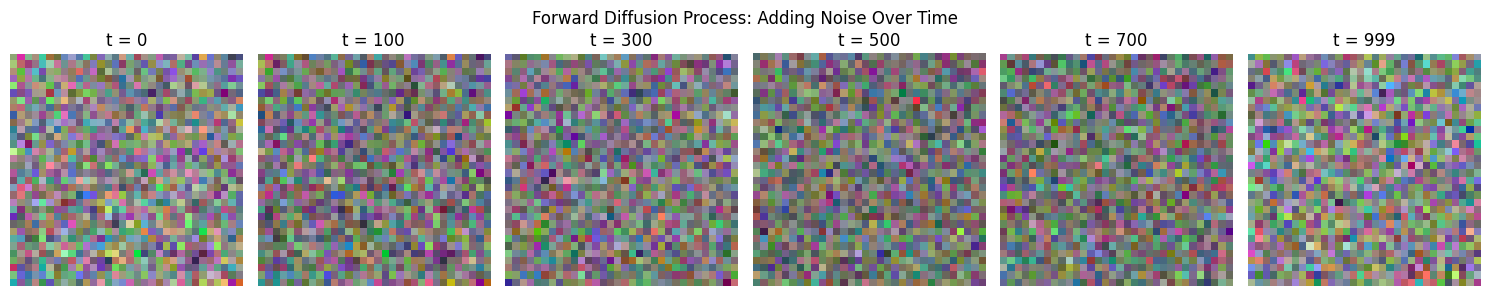

✅ Forward process visualization complete!


In [ ]:
def visualize_forward_process(scheduler, img_size=(3, 32, 32), timesteps_to_show=[0, 100, 300, 500, 700, 999]):
    """
    Visualize the forward diffusion process at various timesteps.
    """
    # Create a sample image (random or could load a real one)
    x_0 = torch.randn(1, *img_size, device=device) * 0.5  # Start with some pattern

    fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

    for idx, t in enumerate(timesteps_to_show):
        t_tensor = torch.tensor([t], device=device)
        x_t, _ = scheduler.perturb_input(x_0, t_tensor)

        img = x_t[0].permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        axes[idx].imshow(img)
        axes[idx].set_title(f't = {t}')
        axes[idx].axis('off')

    plt.suptitle('Forward Diffusion Process: Adding Noise Over Time')
    plt.tight_layout()
    save_fig("ddpm_forward_process.png")
    plt.show()

# Visualize
visualize_forward_process(scheduler)
print("✅ Forward process visualization complete!")

## 1.4 U-Net Architecture for Noise Prediction

A complete U-Net implementation with:
- Sinusoidal time embeddings
- Residual blocks
- Attention mechanisms
- Skip connections

In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    """
    Sinusoidal position embeddings for timestep encoding.
    Similar to the positional encoding in Transformers.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


In [ ]:

class SelfAttention(nn.Module):
    """
    Self-attention mechanism for feature maps.
    """
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.mha = nn.MultiheadAttention(channels, 4, batch_first=True)
        self.ln = nn.LayerNorm([channels])
        self.ff = nn.Sequential(
            nn.LayerNorm([channels]),
            nn.Linear(channels, channels),
            nn.GELU(),
            nn.Linear(channels, channels),
        )

    def forward(self, x):
        size = x.shape[-1]
        x = x.view(-1, self.channels, size * size).transpose(1, 2)
        x_ln = self.ln(x)
        attention_value, _ = self.mha(x_ln, x_ln, x_ln)
        attention_value = attention_value + x
        attention_value = self.ff(attention_value) + attention_value
        return attention_value.transpose(1, 2).view(-1, self.channels, size, size)




In [ ]:

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, kernel_size=4):
        super().__init__()

        self.act = nn.SiLU()
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.transform = nn.Conv2d(out_channels, out_channels, kernel_size, 2, 1)

        num_groups = 32 if out_channels % 32 == 0 else min(out_channels // 4, 8)
        self.bn1 = nn.GroupNorm(num_groups, out_channels)
        self.bn2 = nn.GroupNorm(num_groups, out_channels)

    def forward(self, x, t):
        h = self.act(self.bn1(self.conv1(x)))

        time_emb = self.act(self.time_mlp(t))
        time_emb = time_emb[(...,) + (None,) * 2]
        h = h + time_emb

        h = self.act(self.bn2(self.conv2(h)))
        return h


In [ ]:

class UNet(nn.Module):
    def __init__(self, c_in=1, c_out=1, time_dim=256, base_channels=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.inc = nn.Conv2d(c_in, base_channels, kernel_size=3, padding=1)

        # --- Encoder (Downsampling) ---
        # Down 1: 64 -> 128
        self.down1 = ResidualBlock(base_channels, base_channels * 2, time_dim)
        self.pool1 = nn.Conv2d(base_channels * 2, base_channels * 2, 4, 2, 1) # Downsample
        self.sa1 = SelfAttention(base_channels * 2)

        # Down 2: 128 -> 256
        self.down2 = ResidualBlock(base_channels * 2, base_channels * 4, time_dim)
        self.pool2 = nn.Conv2d(base_channels * 4, base_channels * 4, 4, 2, 1) # Downsample
        self.sa2 = SelfAttention(base_channels * 4)

        # Down 3: 256 -> 256 (Keep channels same to avoid explosion)
        self.down3 = ResidualBlock(base_channels * 4, base_channels * 4, time_dim)
        self.pool3 = nn.Conv2d(base_channels * 4, base_channels * 4, 4, 2, 1) # Downsample
        self.sa3 = SelfAttention(base_channels * 4)

        # --- Bottleneck ---
        self.bot1 = ResidualBlock(base_channels * 4, base_channels * 8, time_dim)
        self.bot2 = ResidualBlock(base_channels * 8, base_channels * 8, time_dim)
        self.bot3 = ResidualBlock(base_channels * 8, base_channels * 4, time_dim)
        self.bot_sa = SelfAttention(base_channels * 4)

        # --- Decoder (Upsampling) ---

        # UP 1
        self.up_trans1 = nn.ConvTranspose2d(base_channels * 4, base_channels * 4, 4, 2, 1)
        # Input: bot_out(256) + skip_h3(256) = 512 channels
        self.up1 = ResidualBlock(base_channels * 8, base_channels * 2, time_dim)
        self.sa4 = SelfAttention(base_channels * 2)

        # UP 2
        self.up_trans2 = nn.ConvTranspose2d(base_channels * 2, base_channels * 2, 4, 2, 1)
        # Input: up1_out(128) + skip_h2(256) = 384 channels
        self.up2 = ResidualBlock(base_channels * 2 + base_channels * 4, base_channels, time_dim)
        self.sa5 = SelfAttention(base_channels)

        # UP 3
        self.up_trans3 = nn.ConvTranspose2d(base_channels, base_channels, 4, 2, 1)
        # Input: up2_out(64) + skip_h1(128) = 192 channels
        self.up3 = ResidualBlock(base_channels + base_channels * 2, base_channels, time_dim)
        self.sa6 = SelfAttention(base_channels)

        self.outc = nn.Conv2d(base_channels, c_out, kernel_size=1)

    def _safe_concat(self, x1, x2):
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        if diffX != 0 or diffY != 0:
            x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        return torch.cat([x1, x2], dim=1)

    def forward(self, x, t):
        t = self.time_mlp(t)

        # Encoder
        x1 = self.inc(x)

        h1 = self.down1(x1, t)
        h1 = self.sa1(h1)
        x2 = self.pool1(h1)

        h2 = self.down2(x2, t)
        h2 = self.sa2(h2)
        x3 = self.pool2(h2)

        h3 = self.down3(x3, t)
        h3 = self.sa3(h3)
        x4 = self.pool3(h3)

        # Bottleneck
        mid = self.bot1(x4, t)
        mid = self.bot2(mid, t)
        mid = self.bot3(mid, t)
        mid = self.bot_sa(mid)

        # Decoder
        # Up 1
        x = self.up_trans1(mid)
        x = self._safe_concat(x, h3) # Concat mid(up) with h3
        x = self.up1(x, t)
        x = self.sa4(x)

        # Up 2
        x = self.up_trans2(x)
        x = self._safe_concat(x, h2) # Concat x with h2
        x = self.up2(x, t)
        x = self.sa5(x)

        # Up 3
        x = self.up_trans3(x)
        x = self._safe_concat(x, h1) # Concat x with h1
        x = self.up3(x, t)
        x = self.sa6(x)

        return self.outc(x)

In [11]:

test_model = UNet(c_in=3, c_out=3, time_dim=256, base_channels=32).to(device)
test_x = torch.randn(2, 3, 32, 32, device=device)
test_t = torch.randint(0, 1000, (2,), device=device)
test_out = test_model(test_x, test_t)


In [12]:
print(f"Input shape: {test_x.shape}")
print(f"Output shape: {test_out.shape}")
print(f"Model parameters: {sum(p.numel() for p in test_model.parameters()):,}")

Input shape: torch.Size([2, 3, 32, 32])
Output shape: torch.Size([2, 3, 32, 32])
Model parameters: 8,127,619


## 1.5 Dataset Preparation

Load a dataset for training. We'll use CIFAR-10 for demonstration.

In [ ]:
DDPM_CONFIG = {
    'image_size': 32,
    'channels': 1,
    'batch_size': 64,
    'learning_rate': 2e-5,
    'num_epochs': 20,
    'num_timesteps': 1000,
    'beta_start': 0.0001,
    'beta_end': 0.02,
}


In [ ]:

transform = transforms.Compose([
    transforms.Resize(DDPM_CONFIG['image_size']),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]) 
])



In [ ]:
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 13.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 406kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.78MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.38MB/s]


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=DDPM_CONFIG['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)


Batch shape: torch.Size([64, 1, 32, 32])
✅ Saved figure: ../report/En_report/figures/ddpm_sample_training_images.png


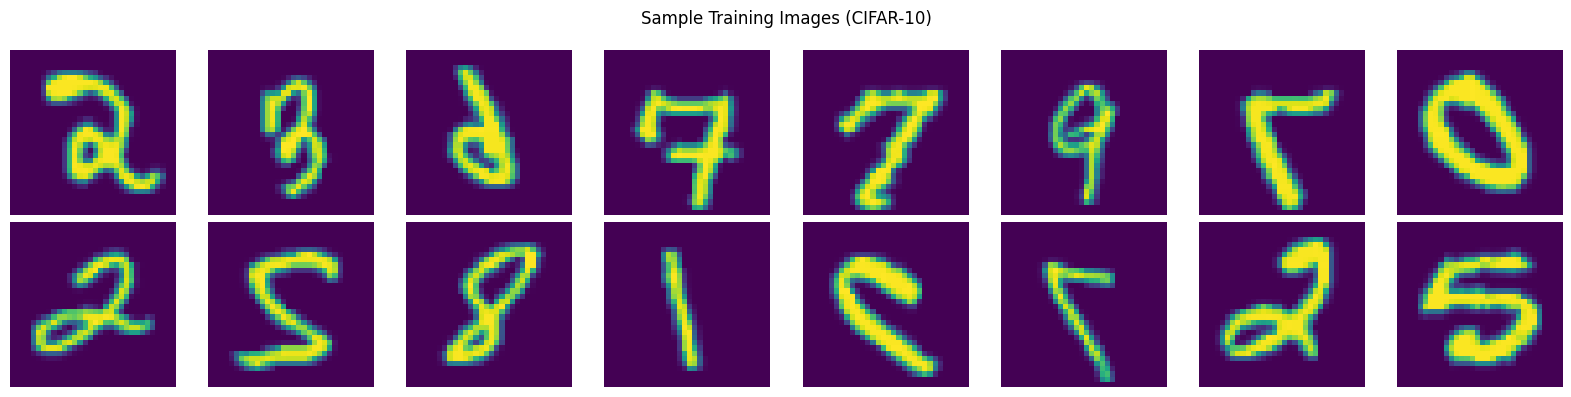

In [ ]:


sample_batch, labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = sample_batch[i].permute(1, 2, 0).numpy()
    img = (img + 1) / 2
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Sample Training Images (CIFAR-10)')
plt.tight_layout()
save_fig("ddpm_sample_training_images.png")
plt.show()

## 1.6 Step 3: DDPM Training Loop

The training loop implements:
1. Sample random timesteps for each image in the batch
2. Add noise to images using the forward process
3. Predict the noise with the U-Net
4. Compute MSE loss between predicted and actual noise
5. Backpropagate and update weights

# Section: Training
This section contains the training loop(s), loss computation, and checkpointing.
Checklist before running:
- Confirm device (`device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')`).
- Confirm optimizer and LR scheduler settings.
- Configure checkpoint path and save frequency.

<details>
<summary><b>Training section — show code / call helpers</b></summary>

Use `train_utils.train_loop()` to replace the standard long loop in the notebook. Example:

```python
from code.modules.train_utils import train_loop
train_loop(model, train_dl, optimizer, device, epochs=3, save_path='results/checkpoint.pt')
```

Expand to view the original detailed loop if you need to modify it directly.
</details>

In [ ]:
class DDPMTrainer:
    """
    Complete DDPM Training Pipeline
    """
    def __init__(self, model, scheduler, optimizer, device):
        self.model = model
        self.scheduler = scheduler
        self.optimizer = optimizer
        self.device = device
        self.loss_history = []

    def train_step(self, x_0):
        """
        Single training step for DDPM.

        Args:
            x_0: Batch of clean images [B, C, H, W]

        Returns:
            loss: MSE loss value
        """
        self.model.train()
        batch_size = x_0.shape[0]

        t = torch.randint(0, self.scheduler.num_timesteps, (batch_size,), device=self.device)
        x_t, noise = self.scheduler.perturb_input(x_0, t)
        noise_pred = self.model(x_t, t)
        loss = F.mse_loss(noise_pred, noise)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)  # Gradient clipping
        self.optimizer.step()

        return loss.item()

    def train_epoch(self, dataloader, epoch):
        """
        Train for one epoch.
        """
        epoch_loss = 0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch}")

        for batch_idx, (images, _) in enumerate(pbar):
            images = images.to(self.device)
            loss = self.train_step(images)
            epoch_loss += loss
            pbar.set_postfix({'loss': f'{loss:.4f}'})

        avg_loss = epoch_loss / len(dataloader)
        self.loss_history.append(avg_loss)
        return avg_loss

    def train(self, dataloader, num_epochs, save_path=None):
        """
        Full training loop.
        """
        print(f"Starting training for {num_epochs} epochs...")

        for epoch in range(1, num_epochs + 1):
            avg_loss = self.train_epoch(dataloader, epoch)
            print(f"Epoch {epoch}/{num_epochs} - Average Loss: {avg_loss:.4f}")

            if save_path and epoch % 5 == 0:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'loss': avg_loss,
                }, f"{save_path}/checkpoint_epoch_{epoch}.pt")

        print("✅ Training complete!")
        return self.loss_history

    def plot_loss(self, save_path=None):
        """Plot training loss curve (and optionally save it for the report)."""
        plt.figure(figsize=(10, 4))
        plt.plot(self.loss_history)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('DDPM Training Loss')
        plt.grid(True)

        if save_path is None and 'REPORT_FIG_DIR' in globals():
            save_path = REPORT_FIG_DIR / "ddpm_training_loss.png"
        if save_path is not None:
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, dpi=200, bbox_inches="tight")
            print(f"✅ Saved: {save_path}")

        plt.show()

In [18]:
ddpm_model = UNet(
    c_in=DDPM_CONFIG['channels'],
    c_out=DDPM_CONFIG['channels'],
    time_dim=256,
    base_channels=64
).to(device)

ddpm_scheduler = DDPMScheduler(
    num_timesteps=DDPM_CONFIG['num_timesteps'],
    beta_start=DDPM_CONFIG['beta_start'],
    beta_end=DDPM_CONFIG['beta_end'],
    device=device
)

optimizer = torch.optim.AdamW(ddpm_model.parameters(), lr=DDPM_CONFIG['learning_rate'])

trainer = DDPMTrainer(ddpm_model, ddpm_scheduler, optimizer, device)

print(f"Model parameters: {sum(p.numel() for p in ddpm_model.parameters()):,}")


Model parameters: 31,525,377


Starting training for 20 epochs...


Epoch 1: 100%|██████████| 938/938 [03:48<00:00,  4.11it/s, loss=0.0281]


Epoch 1/20 - Average Loss: 0.0606


Epoch 2: 100%|██████████| 938/938 [03:48<00:00,  4.11it/s, loss=0.0254]


Epoch 2/20 - Average Loss: 0.0274


...

Epoch 18/20 - Average Loss: 0.0170


Epoch 19: 100%|██████████| 938/938 [03:48<00:00,  4.11it/s, loss=0.0123]


Epoch 19/20 - Average Loss: 0.0169


Epoch 20: 100%|██████████| 938/938 [03:48<00:00,  4.11it/s, loss=0.0128]


Epoch 20/20 - Average Loss: 0.0168
✅ Training complete!
✅ Saved: ../report/En_report/figures/ddpm_training_loss.png


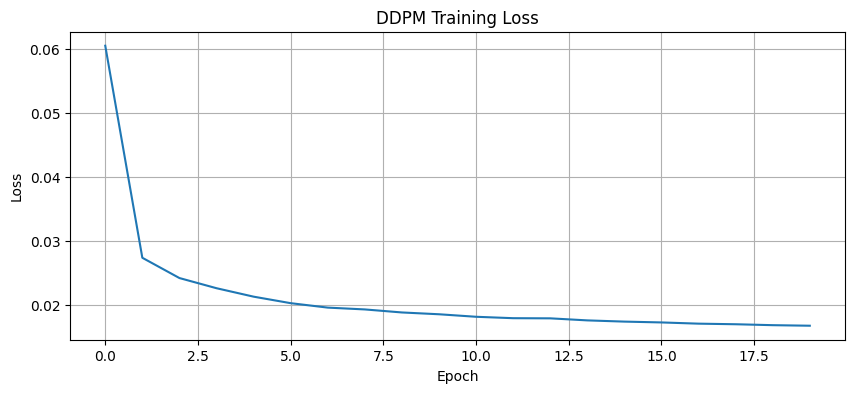

In [19]:
DEMO_EPOCHS = DDPM_CONFIG['num_epochs']

loss_history = trainer.train(train_loader, num_epochs=DEMO_EPOCHS)
trainer.plot_loss(save_path=REPORT_FIG_DIR / "ddpm_training_loss.png")

## 1.7 Step 4: DDPM and DDIM Sampling

Implementing both sampling algorithms:
- **DDPM Sampling**: Stochastic, requires all T timesteps
- **DDIM Sampling**: Deterministic (when η=0), can skip timesteps for faster generation

In [ ]:
class DDPMSampler:
    def __init__(self, model, scheduler, device):
        self.model = model
        self.scheduler = scheduler
        self.device = device

    @torch.no_grad()
    def sample(self, batch_size, img_size=None, show_progress=True):
        """
        Args:
            batch_size: تعداد تصاویر برای تولید
            img_size: ابعاد تصویر (C, H, W). اگر None باشد، از کانفیگ برداشته می‌شود.
        """
        self.model.eval()
        
        if img_size is None:
            c = DDPM_CONFIG.get('channels', 1)
            s = DDPM_CONFIG.get('image_size', 28)
            img_size = (c, s, s)

        x = torch.randn(batch_size, *img_size, device=self.device)

        intermediates = [x.clone()]
        timesteps = reversed(range(self.scheduler.num_timesteps))
        
        if show_progress:
            timesteps = tqdm(timesteps, desc="DDPM Sampling", total=self.scheduler.num_timesteps)

        for t in timesteps:
            t_tensor = torch.full((batch_size,), t, device=self.device, dtype=torch.long)

            noise_pred = self.model(x, t_tensor)

            alpha = self.scheduler.alphas[t]
            alpha_cumprod = self.scheduler.alphas_cumprod[t]
            beta = self.scheduler.betas[t]

            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = (1 / torch.sqrt(alpha)) * (
                x - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * noise_pred
            ) + torch.sqrt(beta) * noise

            if t % 100 == 0:
                intermediates.append(x.clone())

        return x, intermediates

In [ ]:
class DDIMSampler:
    def __init__(self, model, scheduler, device):
        self.model = model
        self.scheduler = scheduler
        self.device = device

    @torch.no_grad()
    def sample(self, batch_size, img_size=None, num_inference_steps=50, eta=0.0, show_progress=True):
        self.model.eval()

        if img_size is None:
            c = DDPM_CONFIG.get('channels', 1)
            s = DDPM_CONFIG.get('image_size', 28)
            img_size = (c, s, s)

        step_ratio = self.scheduler.num_timesteps // num_inference_steps
        timesteps = np.arange(0, self.scheduler.num_timesteps, step_ratio)[::-1].copy()

        x = torch.randn(batch_size, *img_size, device=self.device)

        intermediates = [x.clone()]

        if show_progress:
            timesteps_iter = tqdm(enumerate(timesteps), desc="DDIM Sampling", total=len(timesteps))
        else:
            timesteps_iter = enumerate(timesteps)

        for i, t in timesteps_iter:
            t_tensor = torch.full((batch_size,), t, device=self.device, dtype=torch.long)

            noise_pred = self.model(x, t_tensor)

            alpha_cumprod_t = self.scheduler.alphas_cumprod[t]

            if i < len(timesteps) - 1:
                t_prev = timesteps[i + 1]
                alpha_cumprod_t_prev = self.scheduler.alphas_cumprod[t_prev]
            else:
                alpha_cumprod_t_prev = torch.tensor(1.0, device=self.device)

            pred_x0 = (x - torch.sqrt(1 - alpha_cumprod_t) * noise_pred) / torch.sqrt(alpha_cumprod_t)
            pred_x0 = torch.clamp(pred_x0, -1, 1)

            sigma = eta * torch.sqrt((1 - alpha_cumprod_t_prev) / (1 - alpha_cumprod_t)) * \
                    torch.sqrt(1 - alpha_cumprod_t / alpha_cumprod_t_prev)

            direction = torch.sqrt(1 - alpha_cumprod_t_prev - sigma**2) * noise_pred

            if eta > 0 and i < len(timesteps) - 1:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = torch.sqrt(alpha_cumprod_t_prev) * pred_x0 + direction + sigma * noise

            if i % 10 == 0:
                intermediates.append(x.clone())

        return x, intermediates

In [31]:

ddpm_sampler = DDPMSampler(ddpm_model, ddpm_scheduler, device)
ddim_sampler = DDIMSampler(ddpm_model, ddpm_scheduler, device)



In [32]:
print("Generating samples with DDPM (1000 steps)...")
ddpm_samples, ddpm_intermediates = ddpm_sampler.sample(batch_size=16)


Generating samples with DDPM (1000 steps)...


DDPM Sampling: 100%|██████████| 1000/1000 [00:25<00:00, 39.78it/s]


In [33]:
print("\nGenerating samples with DDIM (50 steps)...")
ddim_samples, ddim_intermediates = ddim_sampler.sample(batch_size=16, num_inference_steps=50, eta=0.0)



Generating samples with DDIM (50 steps)...


DDIM Sampling: 100%|██████████| 50/50 [00:01<00:00, 38.57it/s]


In [34]:
def visualize_samples(samples, title="Generated Samples", save_path=None):
    """Helper function to visualize a batch of samples (and optionally save a grid)."""
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i, ax in enumerate(axes.flat):
        if i < len(samples):
            img = samples[i].permute(1, 2, 0).cpu().numpy()
            img = (img + 1) / 2
            img = np.clip(img, 0, 1)
            ax.imshow(img)
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"✅ Saved: {save_path}")
    plt.show()

✅ Saved: ../report/En_report/figures/ddpm_samples_grid.png


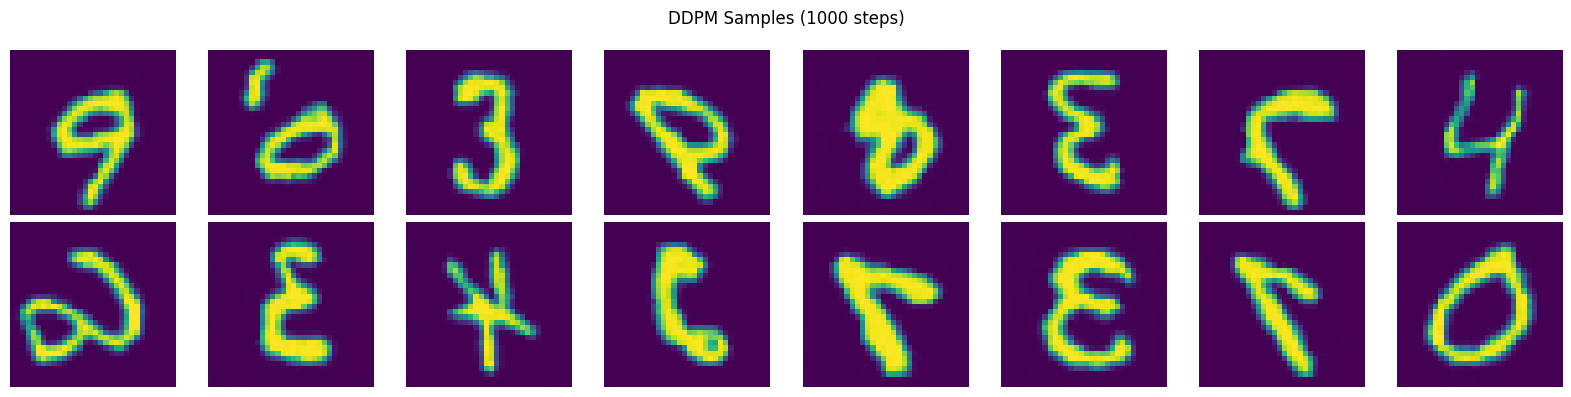

✅ Saved: ../report/En_report/figures/ddim_samples_grid.png


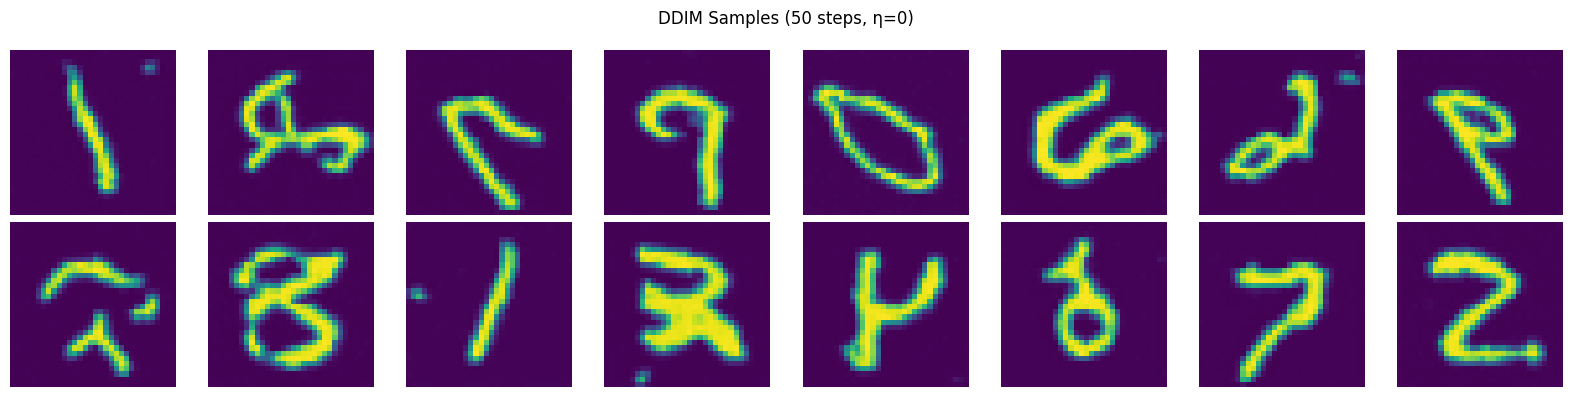

In [35]:
visualize_samples(ddpm_samples, "DDPM Samples (1000 steps)", save_path=REPORT_FIG_DIR / "ddpm_samples_grid.png")
visualize_samples(ddim_samples, "DDIM Samples (50 steps, η=0)", save_path=REPORT_FIG_DIR / "ddim_samples_grid.png")

In [36]:
def visualize_denoising_process(intermediates, title="Denoising Process"):
    """Visualize the progressive denoising."""
    n_steps = min(len(intermediates), 10)
    fig, axes = plt.subplots(1, n_steps, figsize=(2 * n_steps, 2))

    step_indices = np.linspace(0, len(intermediates) - 1, n_steps, dtype=int)

    for idx, step_idx in enumerate(step_indices):
        img = intermediates[step_idx][0].permute(1, 2, 0).cpu().numpy()
        img = (img + 1) / 2
        img = np.clip(img, 0, 1)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Step {step_idx}")
        axes[idx].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()



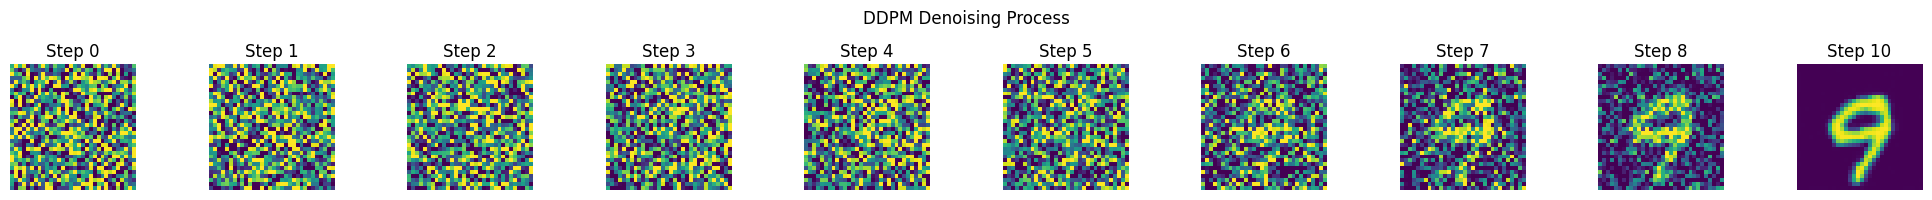

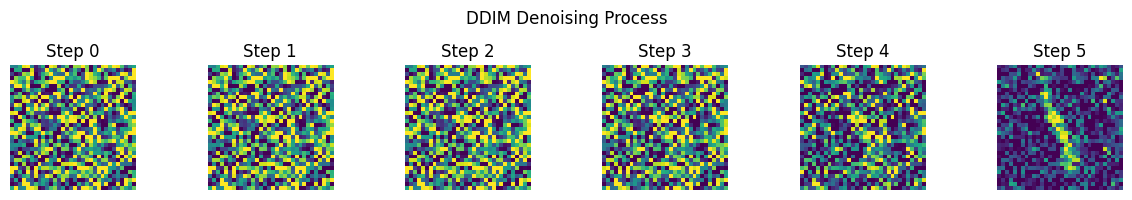

In [37]:
visualize_denoising_process(ddpm_intermediates, "DDPM Denoising Process")
visualize_denoising_process(ddim_intermediates, "DDIM Denoising Process")

---
# Part 2: Stable Diffusion & DreamBooth

## 2.1 Introduction

**Stable Diffusion** performs diffusion in latent space rather than pixel space, significantly reducing computational cost.

Key components:
1. **VAE**: Encodes images to latent space and decodes back
2. **U-Net**: Denoises in latent space
3. **Text Encoder (CLIP)**: Converts text prompts to embeddings

**DreamBooth** is a fine-tuning technique that teaches the model a specific subject using only 3-5 images.

---

In [38]:
try:
    from diffusers import (
        StableDiffusionPipeline,
        DDPMScheduler as DiffusersDDPMScheduler,
        UNet2DConditionModel,
        AutoencoderKL
    )
    from transformers import CLIPTextModel, CLIPTokenizer
    from peft import LoraConfig, get_peft_model
    DIFFUSERS_AVAILABLE = True
    print("✅ Diffusers library available!")
except ImportError:
    DIFFUSERS_AVAILABLE = False
    print("⚠️ Diffusers not installed. Run: pip install diffusers transformers peft accelerate")
    print("   DreamBooth section will use mock implementations for demonstration.")

2026-01-03 21:13:41.137653: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767474821.309686      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767474821.365157      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767474821.790544      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767474821.790584      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767474821.790588      55 computation_placer.cc:177] computation placer alr

✅ Diffusers library available!


## 2.2 Step 1 & 2: DreamBooth Dataset Class

 implementation of the dataset for DreamBooth training with Prior Preservation.

In [ ]:
class DreamBoothDataset(Dataset):
    """
    DreamBooth Dataset for fine-tuning Stable Diffusion.

    Features:
    - Loads instance images (your specific subject, e.g., "sks dog")
    - Optionally loads class images for Prior Preservation (generic dogs)
    - Handles image preprocessing and prompt tokenization

    Args:
        instance_data_root: Path to folder with instance images
        instance_prompt: Prompt describing the instance (e.g., "a photo of sks dog")
        tokenizer: CLIP tokenizer for text encoding
        class_data_root: Optional path to class images for prior preservation
        class_prompt: Generic prompt (e.g., "a photo of a dog")
        size: Image size (default 512 for Stable Diffusion)
        center_crop: Whether to center crop images
    """
    def __init__(
        self,
        instance_data_root,
        instance_prompt,
        tokenizer,
        class_data_root=None,
        class_prompt=None,
        size=512,
        center_crop=False,
    ):
        self.size = size
        self.center_crop = center_crop
        self.tokenizer = tokenizer
        self.instance_prompt = instance_prompt
        self.class_prompt = class_prompt

        self.instance_data_root = Path(instance_data_root)
        if not self.instance_data_root.exists():
            raise ValueError(f"Instance data root doesn't exist: {instance_data_root}")

        image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp']
        self.instance_images_path = []
        for ext in image_extensions:
            self.instance_images_path.extend(list(self.instance_data_root.glob(ext)))

        self.num_instance_images = len(self.instance_images_path)
        if self.num_instance_images == 0:
            raise ValueError(f"No images found in {instance_data_root}")

        print(f"Found {self.num_instance_images} instance images")

        self.class_data_root = None
        self.class_images_path = []
        self.num_class_images = 0

        if class_data_root is not None:
            self.class_data_root = Path(class_data_root)
            self.class_data_root.mkdir(parents=True, exist_ok=True)
            for ext in image_extensions:
                self.class_images_path.extend(list(self.class_data_root.glob(ext)))

            self.num_class_images = len(self.class_images_path)
            print(f"Found {self.num_class_images} class images for prior preservation")

        self._length = max(self.num_class_images, self.num_instance_images)
        if self.num_class_images > 0:
            self._length = self.num_instance_images

        self.image_transforms = transforms.Compose([
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return self._length

    def __getitem__(self, index):
        example = {}

        instance_image_path = self.instance_images_path[index % self.num_instance_images]
        instance_image = Image.open(instance_image_path)

        if not instance_image.mode == "RGB":
            instance_image = instance_image.convert("RGB")
        example["instance_images"] = self.image_transforms(instance_image)

        example["instance_prompt_ids"] = self.tokenizer(
            self.instance_prompt,
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt"
        ).input_ids.squeeze(0)

        if self.class_data_root and self.num_class_images > 0:
            class_image_path = self.class_images_path[index % self.num_class_images]
            class_image = Image.open(class_image_path)

            if not class_image.mode == "RGB":
                class_image = class_image.convert("RGB")

            example["class_images"] = self.image_transforms(class_image)

            example["class_prompt_ids"] = self.tokenizer(
                self.class_prompt,
                padding="max_length",
                truncation=True,
                max_length=self.tokenizer.model_max_length,
                return_tensors="pt"
            ).input_ids.squeeze(0)

        return example


def collate_fn(examples, with_prior_preservation=True):
    """
    Custom collate function for DreamBooth dataloader.
    Combines instance and class examples for prior preservation loss.
    """
    input_ids = [example["instance_prompt_ids"] for example in examples]
    pixel_values = [example["instance_images"] for example in examples]

    if with_prior_preservation and "class_images" in examples[0]:
        input_ids += [example["class_prompt_ids"] for example in examples]
        pixel_values += [example["class_images"] for example in examples]

    pixel_values = torch.stack(pixel_values)
    input_ids = torch.stack(input_ids)

    return {
        "input_ids": input_ids,
        "pixel_values": pixel_values,
    }




## 2.3 Step 3: Generate Class Images (Bonus)

Using the pre-trained Stable Diffusion model to generate class images for prior preservation.

In [ ]:
import hashlib  
def generate_class_images(
    class_data_root, 
    class_prompt, 
    num_class_images=200, 
    model_id="runwayml/stable-diffusion-v1-5", 
    device="cuda"
):
    """
    Generates generic class images (e.g., "a photo of a dog") for Prior Preservation.
    These images are saved to class_data_root to be loaded by the DreamBoothDataset.
    
    Args:
        class_data_root: Folder to save the images.
        class_prompt: The prompt (e.g., "a photo of a dog").
        num_class_images: Total number of images to ensure exist.
        model_id: HuggingFace model ID to use for generation.
    """
    class_data_root = Path(class_data_root)
    class_data_root.mkdir(parents=True, exist_ok=True)
    
    cur_class_images = len(list(class_data_root.glob("*.jpg")) + 
                           list(class_data_root.glob("*.png")))
    
    if cur_class_images >= num_class_images:
        print(f"Found {cur_class_images} class images. No need to generate more.")
        return

    print(f"Generating {num_class_images - cur_class_images} class images for prior preservation...")

    pipe = StableDiffusionPipeline.from_pretrained(
        model_id, 
        torch_dtype=torch.float16
    ).to(device)
    pipe.set_progress_bar_config(disable=True)

    count = cur_class_images
    pbar = tqdm(total=num_class_images, initial=count)
    
    while count < num_class_images:
        images = pipe(class_prompt, num_images_per_prompt=1).images

        for image in images:
            hash_image = hashlib.sha1(image.tobytes()).hexdigest()
            image_filename = class_data_root / f"{hash_image}.jpg"
            
            image.save(image_filename)
            count += 1
            pbar.update(1)
            
            if count >= num_class_images:
                break
    
    del pipe
    torch.cuda.empty_cache()
    print("✅ Class image generation complete.")



In [46]:
results_folder = "."

generate_class_images(
    class_prompt="a photo of a dog",
    class_data_root=results_folder + "class_data",
    num_class_images=100
)

Generating 100 class images for prior preservation...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]


100%|██████████| 100/100 [23:17<00:00, 13.97s/it]

✅ Class image generation complete.


## 2.4 Step 4: DreamBooth Training Loop with LoRA

Complete training loop for DreamBooth with:
- LoRA (Low-Rank Adaptation) for efficient fine-tuning
- Prior preservation loss to prevent catastrophic forgetting
- Mixed precision training support

### Sampling & Inference Guidance
This section performs sampling from the trained model. Quick tips:
- To reproduce results set `seed` and `torch.manual_seed(seed)`.
- `guidance_scale` controls conditioning strength (increase → more faithful to prompt but less diverse).
- For faster sampling try DDIM with fewer steps; for best quality use more DDPM steps.
- Outputs: samples are saved as images in `results/samples/` by default — check path variables above.
- If sampling fails due to memory, reduce `batch_size` or use CPU for small debug runs.


In [ ]:
class DreamBoothTrainer:
    """
    DreamBooth Trainer with LoRA support.

    Implements the full training pipeline:
    1. Encode images to latent space using VAE
    2. Add noise (forward diffusion)
    3. Predict noise with U-Net conditioned on text
    4. Compute loss (with optional prior preservation)
    5. Update only LoRA weights
    """
    def __init__(
        self,
        model_id="runwayml/stable-diffusion-v1-5",
        lora_rank=4,
        learning_rate=1e-4,
        prior_preservation=True,
        prior_loss_weight=1.0,
        device="cuda",
    ):
        self.device = device
        self.prior_preservation = prior_preservation
        self.prior_loss_weight = prior_loss_weight
        self.loss_history = []

        if not DIFFUSERS_AVAILABLE:
            print("⚠️ Diffusers not available. Using mock implementation.")
            self._setup_mock()
            return

        print(f"Loading Stable Diffusion model: {model_id}")

        self.tokenizer = CLIPTokenizer.from_pretrained(
            model_id, subfolder="tokenizer"
        )

        self.text_encoder = CLIPTextModel.from_pretrained(
            model_id, subfolder="text_encoder"
        ).to(device)
        self.text_encoder.requires_grad_(False) 

        self.vae = AutoencoderKL.from_pretrained(
            model_id, subfolder="vae"
        ).to(device)
        self.vae.requires_grad_(False)  

        self.unet = UNet2DConditionModel.from_pretrained(
            model_id, subfolder="unet"
        ).to(device)

        print(f"Applying LoRA with rank {lora_rank}...")
        lora_config = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_rank,
            init_lora_weights="gaussian",
            target_modules=["to_k", "to_q", "to_v", "to_out.0"],
        )
        self.unet = get_peft_model(self.unet, lora_config)
        self.unet.print_trainable_parameters()

        self.noise_scheduler = DiffusersDDPMScheduler.from_pretrained(
            model_id, subfolder="scheduler"
        )
        self.optimizer = torch.optim.AdamW(
            self.unet.parameters(),
            lr=learning_rate,
            weight_decay=1e-2,
        )
        self.scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None
        self.vae_scale_factor = 0.18215

        print("✅ DreamBooth trainer initialized!")

    def _setup_mock(self):
        """Setup mock components when diffusers is not available."""
        self.tokenizer = None
        self.text_encoder = None
        self.vae = None
        self.unet = None
        self.noise_scheduler = None
        self.optimizer = None
        self.scaler = None

    def encode_images(self, images):
        """Encode images to latent space using VAE."""
        with torch.no_grad():
            latents = self.vae.encode(images).latent_dist.sample()
            latents = latents * self.vae_scale_factor
        return latents

    def encode_prompt(self, input_ids):
        """Encode text prompts using CLIP text encoder."""
        with torch.no_grad():
            encoder_hidden_states = self.text_encoder(input_ids)[0]
        return encoder_hidden_states

    def train_step(self, batch):
        """
        Single training step for DreamBooth.

        Args:
            batch: Dictionary with 'pixel_values' and 'input_ids'

        Returns:
            loss: Training loss value
        """
        if not DIFFUSERS_AVAILABLE:
            return 0.0

        self.unet.train()

        pixel_values = batch["pixel_values"].to(self.device)
        input_ids = batch["input_ids"].to(self.device)

        batch_size = pixel_values.shape[0]
        latents = self.encode_images(pixel_values)
        noise = torch.randn_like(latents)

        timesteps = torch.randint(
            0, self.noise_scheduler.config.num_train_timesteps,
            (batch_size,), device=self.device
        ).long()
        noisy_latents = self.noise_scheduler.add_noise(latents, noise, timesteps)
        encoder_hidden_states = self.encode_prompt(input_ids)
        
        with torch.cuda.amp.autocast(enabled=self.scaler is not None):
            noise_pred = self.unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states
            ).sample

            if self.prior_preservation:
                noise_pred_instance, noise_pred_class = noise_pred.chunk(2)
                noise_instance, noise_class = noise.chunk(2)

                instance_loss = F.mse_loss(
                    noise_pred_instance, noise_instance, reduction="mean"
                )
                prior_loss = F.mse_loss(
                    noise_pred_class, noise_class, reduction="mean"
                )

                loss = instance_loss + self.prior_loss_weight * prior_loss
            else:
                loss = F.mse_loss(noise_pred, noise, reduction="mean")

        self.optimizer.zero_grad()

        if self.scaler is not None:
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
        else:
            loss.backward()
            self.optimizer.step()

        return loss.item()

    def train(self, dataloader, num_epochs=100):
        """
        Full training loop.
        """
        if not DIFFUSERS_AVAILABLE:
            print("⚠️ Cannot train without diffusers library.")
            return

        print(f"Starting DreamBooth training for {num_epochs} epochs...")

        for epoch in range(1, num_epochs + 1):
            epoch_loss = 0
            pbar = tqdm(dataloader, desc=f"Epoch {epoch}")

            for batch in pbar:
                loss = self.train_step(batch)
                epoch_loss += loss
                pbar.set_postfix({'loss': f'{loss:.4f}'})

            avg_loss = epoch_loss / len(dataloader)
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch}/{num_epochs} - Loss: {avg_loss:.4f}")

        print("✅ DreamBooth training complete!")

    def save_lora_weights(self, save_path):
        """Save LoRA weights."""
        if not DIFFUSERS_AVAILABLE:
            return

        self.unet.save_pretrained(save_path)
        print(f"✅ LoRA weights saved to {save_path}")

    def plot_loss(self):
        """Plot training loss."""
        plt.figure(figsize=(10, 4))
        plt.plot(self.loss_history)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('DreamBooth Training Loss')
        plt.grid(True)
        plt.show()




## 2.5 Step 5: Inference and Testing

Generate images with the fine-tuned model using different prompts and guidance scales.

# Section: Sampling & Evaluation
Use this section to run DDIM/DDPM sampling, apply classifier-free guidance, and compute evaluation metrics.
- Save sample grids after each major run.
- Compute basic stats (mean, var, volatility) and distribution plots here.
- Use consistent random seed for reproducibility.

<details>
<summary><b>Sampling & Evaluation — show code / call helpers</b></summary>

Use `sampling.sample_ddim()` to run quick deterministic sampling or replace with your DDPM/DDIM implementation:

```python
from code.modules.sampling import sample_ddim
samples = sample_ddim(model, (8, 3, 64, 64), steps=20, device=device)
```

Expand to view the notebook's original sampling cells if you need to tweak schedules or guidance.
</details>

In [ ]:
class DreamBoothInference:
    """
    Inference pipeline for DreamBooth-trained models.
    """
    def __init__(
        self,
        model_id="runwayml/stable-diffusion-v1-5",
        lora_weights_path=None,
        device="cuda"
    ):
        self.device = device

        if not DIFFUSERS_AVAILABLE:
            print("⚠️ Diffusers not available for inference.")
            self.pipeline = None
            return

        print("Loading inference pipeline...")

        self.pipeline = StableDiffusionPipeline.from_pretrained(
            model_id,
            torch_dtype=torch.float16 if device == "cuda" else torch.float32,
            safety_checker=None,
        ).to(device)

        if lora_weights_path:
            print(f"Loading LoRA weights from {lora_weights_path}")
            self.pipeline.load_lora_weights(lora_weights_path)
        print("✅ Inference pipeline ready!")

    @torch.no_grad()
    def generate(
        self,
        prompt,
        negative_prompt="low quality, blurry, distorted",
        num_images=4,
        num_inference_steps=50,
        guidance_scale=7.5,
        seed=None
    ):
        """
        Generate images with the fine-tuned model.

        Args:
            prompt: Text prompt
            negative_prompt: Negative prompt for guidance
            num_images: Number of images to generate
            num_inference_steps: Denoising steps
            guidance_scale: CFG scale (higher = more prompt adherence)
            seed: Random seed for reproducibility

        Returns:
            List of PIL images
        """
        if self.pipeline is None:
            print("⚠️ Pipeline not available.")
            return []

        if seed is not None:
            generator = torch.Generator(device=self.device).manual_seed(seed)
        else:
            generator = None

        images = self.pipeline(
            prompt=[prompt] * num_images,
            negative_prompt=[negative_prompt] * num_images,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=generator,
        ).images

        return images

    def visualize_guidance_scales(self, prompt, scales=[3.0, 5.0, 7.5, 10.0, 15.0]):
        """
        Compare different guidance scales for the same prompt.
        """
        if self.pipeline is None:
            return

        fig, axes = plt.subplots(1, len(scales), figsize=(4*len(scales), 4))

        for idx, scale in enumerate(scales):
            images = self.generate(prompt, num_images=1, guidance_scale=scale, seed=42)
            axes[idx].imshow(images[0])
            axes[idx].set_title(f'CFG Scale: {scale}')
            axes[idx].axis('off')

        plt.suptitle(f'Prompt: "{prompt}"')
        plt.tight_layout()
        plt.show()




In [ ]:
DREAMBOOTH_CONFIG = {
    'instance_data_root': './instance_data',  
    'class_data_root': './class_data',        
    'instance_prompt': 'a photo of sks dog', 
    'class_prompt': 'a photo of a dog',
    'num_class_images': 100,
    'learning_rate': 1e-4,
    'num_epochs': 100,
    'lora_rank': 4,
}



Loading inference pipeline...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/100 [1:28:21<?, ?it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to UNet2DConditionModel found with the prefix='unet'. This is safe to ignore if LoRA state dict didn't originally have any UNet2DConditionModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: h

Loading LoRA weights from ./dreambooth_lora
✅ Inference pipeline ready!
Generating: a photo of a photo of sks dog on the moon


  0%|          | 0/50 [00:00<?, ?it/s]

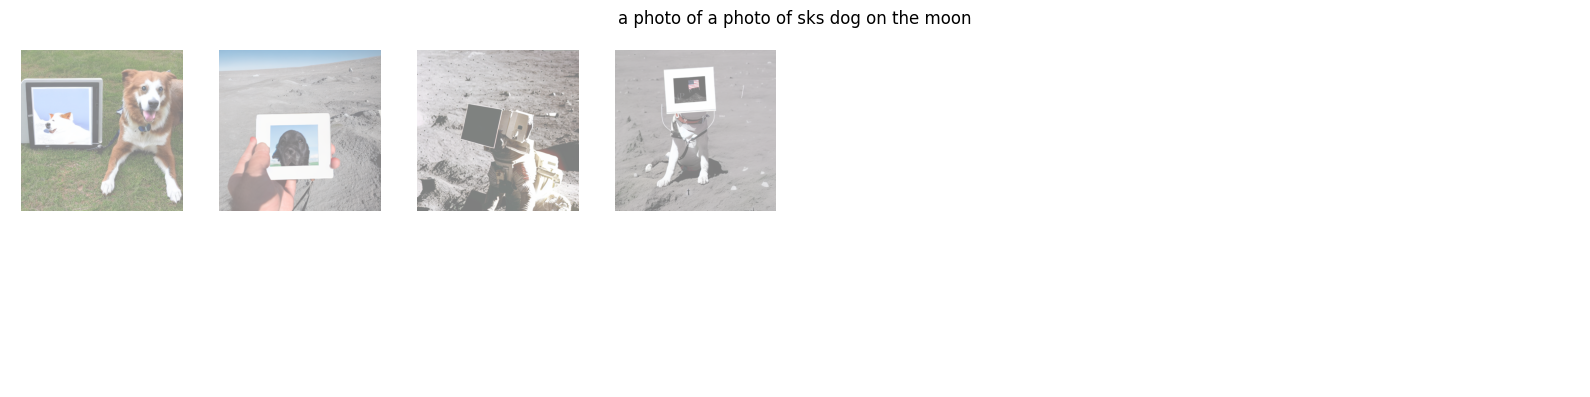

Generating: a photo of a photo of sks dog in a bucket


  0%|          | 0/50 [00:00<?, ?it/s]

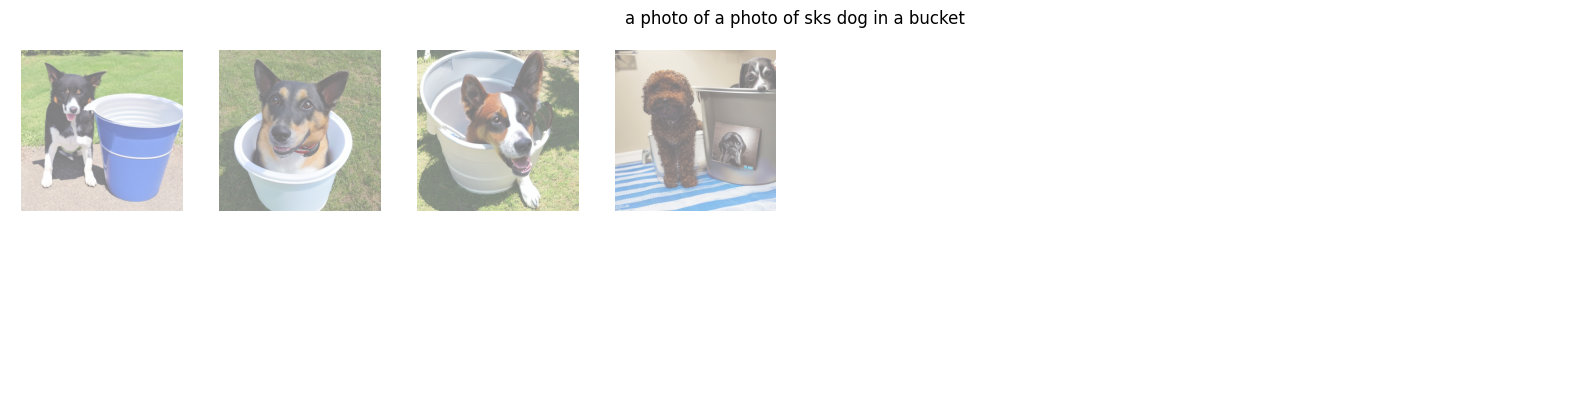

Generating: a painting of a photo of sks dog in the style of Van Gogh


  0%|          | 0/50 [00:00<?, ?it/s]

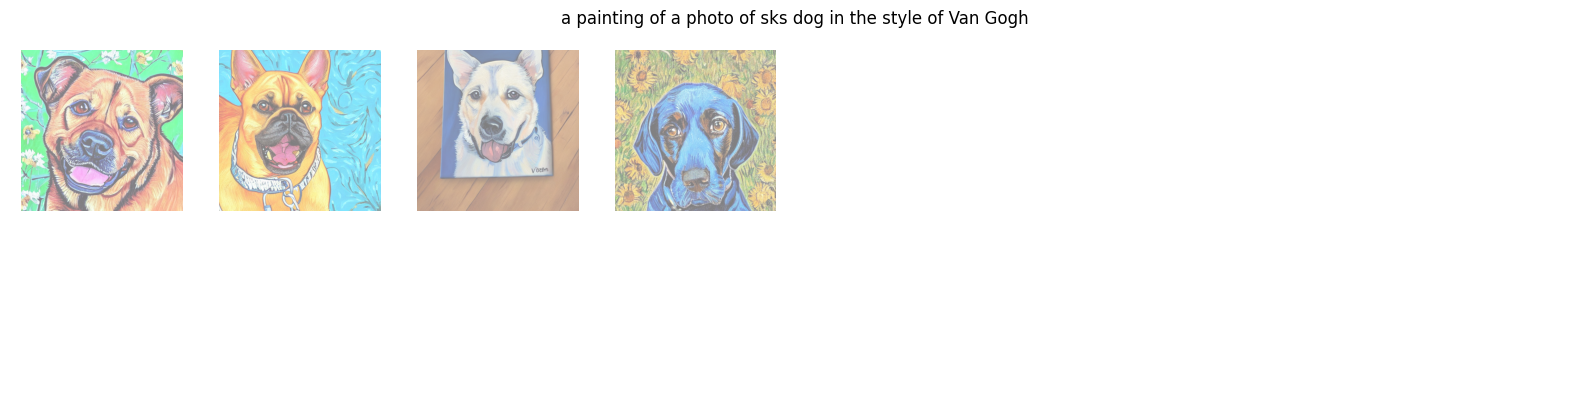

In [ ]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from transformers import CLIPTokenizer

instance_dir = "/kaggle/input/jjjsefe"
class_dir = DREAMBOOTH_CONFIG['class_data_root']

os.makedirs(instance_dir, exist_ok=True)
os.makedirs(class_dir, exist_ok=True)

if DIFFUSERS_AVAILABLE:
    if len(os.listdir(class_dir)) < DREAMBOOTH_CONFIG['num_class_images']:
        print("Generating class images for prior preservation...")
        generate_class_images(
            class_prompt=DREAMBOOTH_CONFIG['class_prompt'],
            class_data_root=class_dir,
            num_class_images=DREAMBOOTH_CONFIG['num_class_images']
        )

if DIFFUSERS_AVAILABLE:
    tokenizer = CLIPTokenizer.from_pretrained(
        "runwayml/stable-diffusion-v1-5", subfolder="tokenizer"
    )

    train_dataset = DreamBoothDataset(
        instance_data_root=instance_dir,
        instance_prompt=DREAMBOOTH_CONFIG['instance_prompt'],
        tokenizer=tokenizer,
        class_data_root=class_dir,
        class_prompt=DREAMBOOTH_CONFIG['class_prompt'],
        size=512,
    )

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=1,
        shuffle=True,
        collate_fn=lambda x: collate_fn(x, with_prior_preservation=True)
    )
if DIFFUSERS_AVAILABLE:
    dreambooth_trainer = DreamBoothTrainer(
        lora_rank=DREAMBOOTH_CONFIG['lora_rank'],
        learning_rate=DREAMBOOTH_CONFIG['learning_rate'],
        prior_preservation=True,
    )

    dreambooth_trainer.train(train_dataloader, num_epochs=DREAMBOOTH_CONFIG['num_epochs'])
    
    save_path = './dreambooth_lora'
    dreambooth_trainer.save_lora_weights(save_path)
    dreambooth_trainer.plot_loss()

if DIFFUSERS_AVAILABLE:
    inference = DreamBoothInference(lora_weights_path=save_path)

    test_prompts = [
        f"a photo of {DREAMBOOTH_CONFIG['instance_prompt']} on the moon",
        f"a photo of {DREAMBOOTH_CONFIG['instance_prompt']} in a bucket",
        f"a painting of {DREAMBOOTH_CONFIG['instance_prompt']} in the style of Van Gogh"
    ]

    for prompt in test_prompts:
        print(f"Generating: {prompt}")
        images = inference.generate(prompt, num_images=4)
        visualize_samples(torch.stack([
            transforms.ToTensor()(img) for img in images
        ]), title=prompt)

---
# Part 3: Flow Matching for Time Series

## 3.1 Introduction

**Flow Matching** is a continuous generative model that learns a time-dependent vector field $v_t(x)$ to transport samples from noise distribution $p_0$ to data distribution $p_1$.

Key equations:
- **ODE**: $\frac{dx}{dt} = v_t(x)$
- **Linear interpolation**: $x_t = (1-t)x_0 + tx_1$ where $x_0 \sim \mathcal{N}(0, I)$, $x_1 \sim p_{data}$
- **Target vector field**: $v_t(x_t) = x_1 - x_0$

This section implements Flow Matching for generating realistic financial time series (log-returns).

---

In [ ]:
import pandas as pd
from scipy import stats
from scipy.ndimage import gaussian_filter1d

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except ImportError:
    YFINANCE_AVAILABLE = False
    print("⚠️ yfinance not installed. Run: pip install yfinance")
    print("   Using synthetic data for demonstration.")



✅ Part 3 imports ready!


## 3.2 Data Preparation

Loading SPY (S&P 500 ETF) data and preparing log-returns for training.

In [ ]:
class TimeSeriesDataset(Dataset):
    """
    Dataset for financial time series log-returns.
    """
    def __init__(self, data, seq_len=64):
        """
        Args:
            data: 1D numpy array of log-returns
            seq_len: Length of each sequence
        """
        self.seq_len = seq_len
        self.data = torch.tensor(data, dtype=torch.float32)
        num_sequences = len(data) - seq_len + 1
        self.sequences = torch.zeros(num_sequences, seq_len, 1)

        for i in range(num_sequences):
            self.sequences[i, :, 0] = self.data[i:i + seq_len]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def load_spy_data(start_date="2010-01-01", end_date="2023-12-31", seq_len=64):
    """
    Load SPY data and prepare log-returns.

    Returns:
s         train_dataset, test_dataset, scaler_params (mean, std)
    """
    if YFINANCE_AVAILABLE:
        print(f"Downloading SPY data from {start_date} to {end_date}...")
        spy = yf.download("SPY", start=start_date, end=end_date, progress=False)

        cols = spy.columns
        if isinstance(cols, pd.MultiIndex):
            if 'Price' in cols.names:
                price_level = cols.names.index('Price')
            else:
                price_level = 0
            price_names = cols.get_level_values(price_level)
            if 'Adj Close' in price_names:
                prices_series = spy.xs('Adj Close', axis=1, level=price_level)
            elif 'Close' in price_names:
                prices_series = spy.xs('Close', axis=1, level=price_level)
            else:
                raise ValueError(f"Could not find 'Adj Close' or 'Close' in MultiIndex columns: {cols}")
            if isinstance(prices_series, pd.DataFrame):
                prices = prices_series.iloc[:, 0].values
            else:
                prices = prices_series.values
        else:
            if 'Adj Close' in cols:
                prices = spy['Adj Close'].values
            elif 'Close' in cols:
                prices = spy['Close'].values
            else:
                raise ValueError(f"Could not find 'Adj Close' or 'Close' in columns: {list(cols)}")
    else:
        print("Using synthetic data (yfinance not available)...")
        np.random.seed(42)
        n_days = 3500 
        returns = np.random.normal(0.0003, 0.012, n_days)
        prices = 100 * np.exp(np.cumsum(returns))

    log_returns = np.diff(np.log(prices))
    log_returns = log_returns[~np.isnan(log_returns)]

    mean = np.mean(log_returns)
    std = np.std(log_returns)
    log_returns_normalized = (log_returns - mean) / std

    print(f"Data shape: {log_returns.shape}")
    print(f"Mean: {mean:.6f}, Std: {std:.6f}")

    split_idx = int(len(log_returns_normalized) * 0.9)
    train_data = log_returns_normalized[:split_idx]
    test_data = log_returns_normalized[split_idx:]
    
    print(f"Train samples: {len(train_data)}, Test samples: {len(test_data)}")
    train_dataset = TimeSeriesDataset(train_data, seq_len=seq_len)
    test_dataset = TimeSeriesDataset(test_data, seq_len=seq_len)
    print(f"Train sequences: {len(train_dataset)}, Test sequences: {len(test_dataset)}")

    return train_dataset, test_dataset, {'mean': mean, 'std': std}



In [ ]:

FM_CONFIG = {
    'seq_len': 64,
    'batch_size': 512,
    'learning_rate': 2e-4,
    'num_epochs': 100,
    'hidden_dim': 256,
    'num_layers': 4,
}



Data shape: (3521,)
Mean: 0.000482, Std: 0.010947
Train samples: 3168, Test samples: 353
Train sequences: 3105, Test sequences: 290


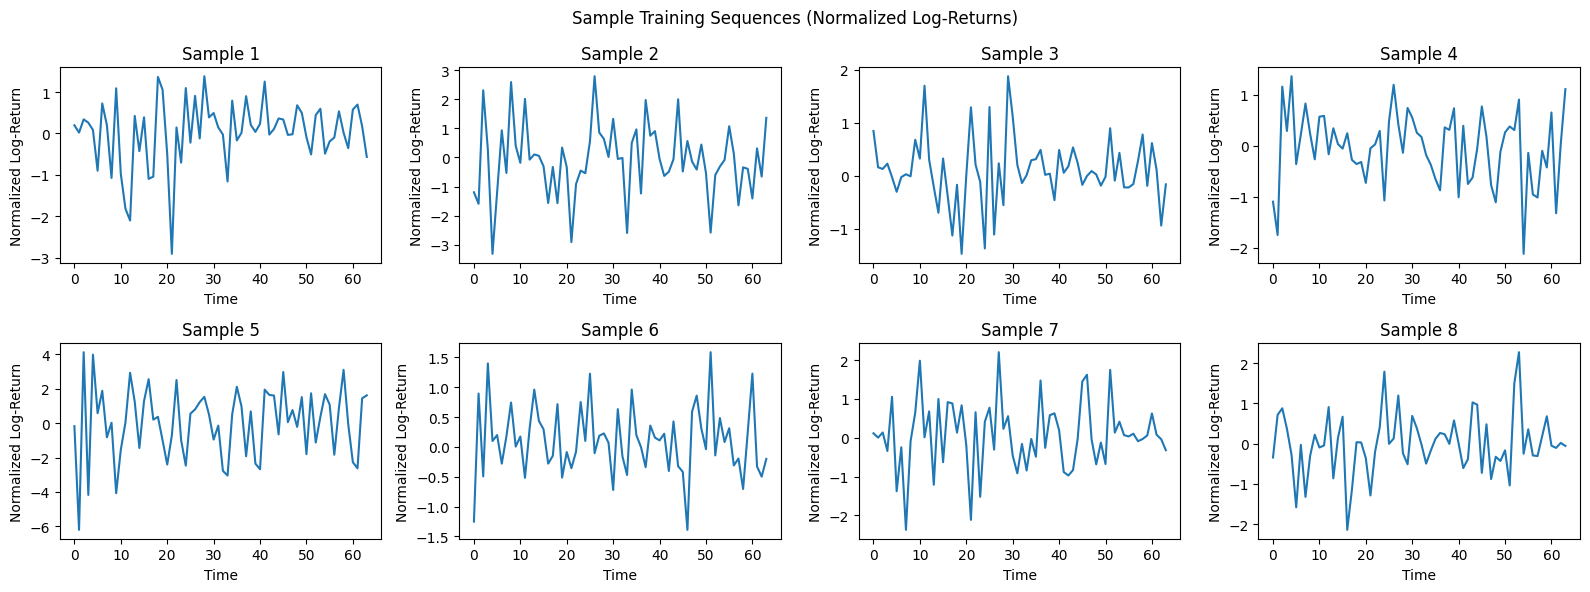

In [ ]:
train_dataset, test_dataset, scaler_params = load_spy_data(seq_len=FM_CONFIG['seq_len'])

train_loader = DataLoader(train_dataset, batch_size=FM_CONFIG['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=FM_CONFIG['batch_size'], shuffle=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    sample = train_dataset[i * 100].squeeze().numpy()
    ax.plot(sample)
    ax.set_title(f'Sample {i+1}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Normalized Log-Return')
plt.suptitle('Sample Training Sequences (Normalized Log-Returns)')
plt.tight_layout()
plt.show()

## 3.3 Vector Field Network

Neural network that predicts the vector field $v_t(x)$ for Flow Matching.

In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    """
    Sinusoidal time embedding for continuous time t ∈ [0, 1].
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings



In [ ]:




class VectorFieldTransformer(nn.Module):
    """
    Transformer-based Vector Field Network for better temporal modeling.
    """
    def __init__(self, seq_len, feature_dim=1, hidden_dim=128, num_heads=4, num_layers=4):
        super().__init__()

        self.seq_len = seq_len
        self.feature_dim = feature_dim
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len, hidden_dim) * 0.02)
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )
        self.input_proj = nn.Linear(feature_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(hidden_dim, feature_dim)

    def forward(self, x, t):
        """
        Forward pass.

        Args:
            x: [B, L, F] intermediate data
            t: [B] time values ∈ [0, 1]

        Returns:
            v: [B, L, F] predicted vector field
        """
        B, L, F = x.shape
        h = self.input_proj(x)  
        h = h + self.pos_embed[:, :L, :]
        t_emb = self.time_embed(t)  
        h = h + t_emb.unsqueeze(1) 
        h = self.transformer(h)
        v = self.output_proj(h)

        return v




In [ ]:
class VectorFieldMLP(nn.Module):
    """
    MLP-based Vector Field Network for Flow Matching.

    Input: x_t (intermediate data) + t (time)
    Output: v_t(x_t) (predicted velocity/direction)
    """
    def __init__(self, input_dim, hidden_dim=256, num_layers=4, time_embed_dim=64):
        super().__init__()

        self.input_dim = input_dim
        self.time_embed_dim = time_embed_dim
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(time_embed_dim),
            nn.Linear(time_embed_dim, hidden_dim),
            nn.SiLU(),
        )
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        layers = []
        for i in range(num_layers):
            layers.extend([
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.SiLU(),
                nn.Dropout(0.1),
            ])
        self.net = nn.Sequential(*layers)
        self.output_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, t):
        """
        Forward pass.

        Args:
            x: [B, L, F] intermediate data
            t: [B] time values ∈ [0, 1]

        Returns:
            v: [B, L, F] predicted vector field
        """
        B, L, F = x.shape
        x_flat = x.view(B, -1)
        h = self.input_proj(x_flat)
        t_emb = self.time_embed(t) 
        h = h + t_emb
        h = self.net(h)
        v = self.output_proj(h)

        return v.view(B, L, F)

In [ ]:
mlp_model = VectorFieldMLP(
    input_dim=FM_CONFIG['seq_len'],
    hidden_dim=FM_CONFIG['hidden_dim'],
    num_layers=FM_CONFIG['num_layers']
).to(device)

transformer_model = VectorFieldTransformer(
    seq_len=FM_CONFIG['seq_len'],
    hidden_dim=FM_CONFIG['hidden_dim'],
    num_layers=FM_CONFIG['num_layers']
).to(device)



In [ ]:
test_x = torch.randn(4, FM_CONFIG['seq_len'], 1, device=device)
test_t = torch.rand(4, device=device)

mlp_out = mlp_model(test_x, test_t)
transformer_out = transformer_model(test_x, test_t)

print(f"MLP model parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")
print(f"Transformer model parameters: {sum(p.numel() for p in transformer_model.parameters()):,}")
print(f"Input shape: {test_x.shape}, Output shape: {mlp_out.shape}")


MLP model parameters: 314,944
Transformer model parameters: 3,241,985
Input shape: torch.Size([4, 64, 1]), Output shape: torch.Size([4, 64, 1])


## 3.4 Flow Matching Training

Training the vector field network with the Flow Matching objective:
$$\mathcal{L}_{FM} = \mathbb{E}_{t, x_0, x_1} \|v_\theta(x_t, t) - (x_1 - x_0)\|^2$$

where $x_t = (1-t)x_0 + tx_1$ (linear interpolation / optimal transport path).

In [ ]:
import numpy as np
import pandas as pd
try:
    import yfinance as yf
    _YF_AVAILABLE = True
except ImportError:
    _YF_AVAILABLE = False


def get_spy_prices(start_date="2010-01-01", end_date="2023-12-31"):
    if _YF_AVAILABLE:
        spy_df = yf.download("SPY", start=start_date, end=end_date, progress=False)
        cols = spy_df.columns
        if isinstance(cols, pd.MultiIndex):
            if 'Price' in cols.names:
                price_level = cols.names.index('Price')
            else:
                price_level = 0
            price_names = cols.get_level_values(price_level)
            if 'Adj Close' in price_names:
                prices_series = spy_df.xs('Adj Close', axis=1, level=price_level)
            elif 'Close' in price_names:
                prices_series = spy_df.xs('Close', axis=1, level=price_level)
            else:
                raise ValueError(f"Could not find Adj Close/Close in columns: {cols}")
            prices = prices_series.iloc[:, 0].values if isinstance(prices_series, pd.DataFrame) else prices_series.values
        else:
            if 'Adj Close' in cols:
                prices = spy_df['Adj Close'].values
            elif 'Close' in cols:
                prices = spy_df['Close'].values
            else:
                raise ValueError(f"Could not find Adj Close/Close in columns: {list(cols)}")
    else:
        np.random.seed(42)
        n_days = 3500
        returns = np.random.normal(0.0003, 0.012, n_days)
        prices = 100 * np.exp(np.cumsum(returns))
        dates = pd.date_range(start=start_date, periods=n_days, freq='B')
        spy_df = pd.DataFrame({'Adj Close': prices}, index=dates)
    return spy_df, prices



Loaded SPY data with 3522 prices; columns: [('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]


In [ ]:
spy, prices = get_spy_prices()
print(f"Loaded SPY data with {len(prices)} prices; columns: {list(spy.columns)}")


In [ ]:

def extract_prices(spy_df):
    cols = spy_df.columns
    if isinstance(cols, pd.MultiIndex):
        if 'Price' in cols.names:
            price_level = cols.names.index('Price')
        else:
            price_level = 0
        price_names = cols.get_level_values(price_level)
        if 'Adj Close' in price_names:
            prices_series = spy_df.xs('Adj Close', axis=1, level=price_level)
        elif 'Close' in price_names:
            prices_series = spy_df.xs('Close', axis=1, level=price_level)
        else:
            raise ValueError(f"Could not find Adj Close/Close in columns: {cols}")
        return prices_series.iloc[:, 0].values if isinstance(prices_series, pd.DataFrame) else prices_series.values
    else:
        if 'Adj Close' in cols:
            return spy_df['Adj Close'].values
        elif 'Close' in cols:
            return spy_df['Close'].values
        else:
            raise ValueError(f"Could not find Adj Close/Close in columns: {list(cols)}")



Prices extracted with shape (3522,)


In [ ]:
prices = extract_prices(spy)
print(f"Prices extracted with shape {prices.shape}")


In [74]:
prices = extract_prices(spy)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math
from pathlib import Path
from tqdm import tqdm
import os
from scipy import stats
from scipy.ndimage import gaussian_filter1d

try:
    import pandas as pd
    PANDAS_AVAILABLE = True
except ImportError:
    PANDAS_AVAILABLE = False

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except ImportError:
    YFINANCE_AVAILABLE = False


In [ ]:


FM_CONFIG = {
    'seq_len': 64,
    'batch_size': 512,
    'learning_rate': 2e-4,
    'num_epochs': 100,
    'hidden_dim': 256,
    'num_layers': 4,
}


In [ ]:


class TimeSeriesDataset(Dataset):
    """
    Dataset for financial time series log-returns.
    """
    def __init__(self, data, seq_len=64):
        """
        Args:
            data: 1D numpy array of log-returns
            seq_len: Length of each sequence
        """
        self.seq_len = seq_len
        self.data = torch.tensor(data, dtype=torch.float32)

        num_sequences = len(data) - seq_len + 1
        self.sequences = torch.zeros(num_sequences, seq_len, 1)

        for i in range(num_sequences):
            self.sequences[i, :, 0] = self.data[i:i + seq_len]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


In [ ]:


def load_spy_data(start_date="2010-01-01", end_date="2023-12-31", seq_len=64):
    """
    Load SPY data and prepare log-returns.

    Returns:
        train_dataset, test_dataset, scaler_params (mean, std)
    """
    if YFINANCE_AVAILABLE:
        print(f"Downloading SPY data from {start_date} to {end_date}...")
        spy = yf.download("SPY", start=start_date, end=end_date, progress=False)

        cols = spy.columns
        if isinstance(cols, pd.MultiIndex):
            if 'Price' in cols.names:
                price_level = cols.names.index('Price')
            else:
                price_level = 0
            price_names = cols.get_level_values(price_level)
            if 'Adj Close' in price_names:
                prices_series = spy.xs('Adj Close', axis=1, level=price_level)
            elif 'Close' in price_names:
                prices_series = spy.xs('Close', axis=1, level=price_level)
            else:
                raise ValueError(f"Could not find 'Adj Close' or 'Close' in MultiIndex columns: {cols}")
            if isinstance(prices_series, pd.DataFrame):
                prices = prices_series.iloc[:, 0].values
            else:
                prices = prices_series.values
        else:
            if 'Adj Close' in cols:
                prices = spy['Adj Close'].values
            elif 'Close' in cols:
                prices = spy['Close'].values
            else:
                raise ValueError(f"Could not find 'Adj Close' or 'Close' in columns: {list(cols)}")
    else:
        print("Using synthetic data (yfinance not available)...")
        np.random.seed(42)
        n_days = 3500  
        returns = np.random.normal(0.0003, 0.012, n_days)
        prices = 100 * np.exp(np.cumsum(returns))

    log_returns = np.diff(np.log(prices))
    log_returns = log_returns[~np.isnan(log_returns)]

    mean = np.mean(log_returns)
    std = np.std(log_returns)
    log_returns_normalized = (log_returns - mean) / std

    print(f"Data shape: {log_returns.shape}")
    print(f"Mean: {mean:.6f}, Std: {std:.6f}")

    split_idx = int(len(log_returns_normalized) * 0.9)
    train_data = log_returns_normalized[:split_idx]
    test_data = log_returns_normalized[split_idx:]

    print(f"Train samples: {len(train_data)}, Test samples: {len(test_data)}")

    train_dataset = TimeSeriesDataset(train_data, seq_len=seq_len)
    test_dataset = TimeSeriesDataset(test_data, seq_len=seq_len)

    print(f"Train sequences: {len(train_dataset)}, Test sequences: {len(test_dataset)}")
    return train_dataset, test_dataset, {'mean': mean, 'std': std}



In [ ]:

class SinusoidalTimeEmbedding(nn.Module):
    """
    Sinusoidal time embedding for continuous time t ∈ [0, 1].
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


In [ ]:


class VectorFieldMLP(nn.Module):
    """
    MLP-based Vector Field Network for Flow Matching.

    Input: x_t (intermediate data) + t (time)
    Output: v_t(x_t) (predicted velocity/direction)
    """
    def __init__(self, input_dim, hidden_dim=256, num_layers=4, time_embed_dim=64):
        super().__init__()

        self.input_dim = input_dim
        self.time_embed_dim = time_embed_dim

        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(time_embed_dim),
            nn.Linear(time_embed_dim, hidden_dim),
            nn.SiLU(),
        )

        self.input_proj = nn.Linear(input_dim, hidden_dim)

        layers = []
        for i in range(num_layers):
            layers.extend([
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.SiLU(),
                nn.Dropout(0.1),
            ])
        self.net = nn.Sequential(*layers)
        self.output_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, t):
        """
        Forward pass.

        Args:
            x: [B, L, F] intermediate data
            t: [B] time values ∈ [0, 1]

        Returns:
            v: [B, L, F] predicted vector field
        """
        B, L, F = x.shape
        x_flat = x.view(B, -1)
        h = self.input_proj(x_flat)
        t_emb = self.time_embed(t)
        h = h + t_emb
        h = self.net(h)
        v = self.output_proj(h)
        return v.view(B, L, F)



In [ ]:

class VectorFieldTransformer(nn.Module):
    """
    Transformer-based Vector Field Network for better temporal modeling.
    """
    def __init__(self, seq_len, feature_dim=1, hidden_dim=128, num_heads=4, num_layers=4):
        super().__init__()

        self.seq_len = seq_len
        self.feature_dim = feature_dim

        self.pos_embed = nn.Parameter(torch.randn(1, seq_len, hidden_dim) * 0.02)

        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )

        self.input_proj = nn.Linear(feature_dim, hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(hidden_dim, feature_dim)

    def forward(self, x, t):
        """
        Forward pass.

        Args:
            x: [B, L, F] intermediate data
            t: [B] time values ∈ [0, 1]

        Returns:
            v: [B, L, F] predicted vector field
        """
        B, L, F = x.shape

        h = self.input_proj(x) 

        h = h + self.pos_embed[:, :L, :]
        t_emb = self.time_embed(t) 
        h = h + t_emb.unsqueeze(1)  
        h = self.transformer(h)

        v = self.output_proj(h)

        return v


In [ ]:


class FlowMatchingTrainer:
    """
    Flow Matching Trainer for time series generation.

    Implements the Flow Matching objective:
    L_FM = E_{t,x_0,x_1} ||v_θ(x_t, t) - (x_1 - x_0)||^2

    where x_t = (1-t)x_0 + t*x_1 (linear interpolation)
    """
    def __init__(self, model, optimizer, device):
        self.model = model
        self.optimizer = optimizer
        self.device = device
        self.train_loss_history = []
        self.test_loss_history = []

    def sample_time_and_data(self, batch):
        """
        Sample t, x_0, x_1 for Flow Matching.

        Args:
            batch: [B, L, F] batch of data sequences

        Returns:
            x_t: [B, L, F] interpolated data at time t
            target_v: [B, L, F] target vector field (x_1 - x_0)
            t: [B] sampled times
        """
        B, L, F = batch.shape
        x_0 = batch 
        x_1 = torch.roll(batch, shifts=1, dims=0)
        t = torch.rand(B, device=self.device)
        t_expanded = t.view(B, 1, 1)
        x_t = (1 - t_expanded) * x_0 + t_expanded * x_1
        target_v = x_1 - x_0

        return x_t, target_v, t

    def train_step(self, batch):
        """
        Single training step.

        Args:
            batch: [B, L, F] batch of sequences

        Returns:
            loss: Flow Matching loss
        """
        self.model.train()
        x_t, target_v, t = self.sample_time_and_data(batch)
        pred_v = self.model(x_t, t)
        loss = F.mse_loss(pred_v, target_v)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()

        return loss.item()

    def test_step(self, batch):
        """
        Single test step (no gradients).
        """
        self.model.eval()
        with torch.no_grad():
            x_t, target_v, t = self.sample_time_and_data(batch)
            pred_v = self.model(x_t, t)
            loss = F.mse_loss(pred_v, target_v)
        return loss.item()

    def train_epoch(self, train_loader, epoch):
        """Train for one epoch."""
        epoch_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}")

        for batch in pbar:
            batch = batch.to(self.device)
            loss = self.train_step(batch)
            epoch_loss += loss
            pbar.set_postfix({'loss': f'{loss:.4f}'})

        avg_loss = epoch_loss / len(train_loader)
        self.train_loss_history.append(avg_loss)
        return avg_loss

    def test_epoch(self, test_loader):
        """Test for one epoch."""
        epoch_loss = 0

        for batch in test_loader:
            batch = batch.to(self.device)
            loss = self.test_step(batch)
            epoch_loss += loss

        avg_loss = epoch_loss / len(test_loader)
        self.test_loss_history.append(avg_loss)
        return avg_loss

    def train(self, train_loader, test_loader, num_epochs):
        """
        Full training loop.
        """
        print(f"Starting Flow Matching training for {num_epochs} epochs...")

        for epoch in range(1, num_epochs + 1):
            train_loss = self.train_epoch(train_loader, epoch)
            test_loss = self.test_epoch(test_loader)

            print(f"Epoch {epoch}/{num_epochs} - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

        print("✅ Flow Matching training complete!")

    def plot_loss(self):
        """Plot training and test loss curves."""
        plt.figure(figsize=(10, 4))
        plt.plot(self.train_loss_history, label='Train Loss')
        plt.plot(self.test_loss_history, label='Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Flow Matching Training Loss')
        plt.legend()
        plt.grid(True)
        plt.show()


In [ ]:


class FlowMatchingSampler:
    """
    ODE Sampler for Flow Matching.

    Solves the ODE: dx/dt = v_θ(x, t)
    from t=0 (Gaussian noise) to t=1 (data distribution)

    Available solvers:
    - Euler: Simple first-order method
    - Heun: Second-order Runge-Kutta
    - RK4: Fourth-order Runge-Kutta (more accurate)
    """
    def __init__(self, model, device):
        self.model = model
        self.device = device

    @torch.no_grad()
    def euler_step(self, x, t, dt):
        """Euler method: x_{t+dt} = x_t + v(x_t, t) * dt"""
        v = self.model(x, t)
        return x + v * dt

    @torch.no_grad()
    def heun_step(self, x, t, dt):
        """Heun's method (2nd order RK): Predictor-Corrector"""
        # Predictor (Euler step)
        v1 = self.model(x, t)
        x_pred = x + v1 * dt

        # Corrector
        t_next = t + dt
        t_next = torch.clamp(t_next, 0, 1)
        v2 = self.model(x_pred, t_next)

        return x + (v1 + v2) * dt / 2

    @torch.no_grad()
    def rk4_step(self, x, t, dt):
        """Fourth-order Runge-Kutta (RK4)"""
        k1 = self.model(x, t)
        k2 = self.model(x + k1 * dt / 2, torch.clamp(t + dt / 2, 0, 1))
        k3 = self.model(x + k2 * dt / 2, torch.clamp(t + dt / 2, 0, 1))
        k4 = self.model(x + k3 * dt, torch.clamp(t + dt, 0, 1))

        return x + (k1 + 2*k2 + 2*k3 + k4) * dt / 6

    @torch.no_grad()
    def sample(self, n_samples, seq_len, feature_dim=1, n_steps=100, solver='euler', return_trajectory=False):
        """
        Generate samples using the trained vector field.

        Args:
            n_samples: Number of samples to generate
            seq_len: Sequence length
            feature_dim: Feature dimension
            n_steps: Number of ODE solver steps
            solver: 'euler', 'heun', or 'rk4'
            return_trajectory: Whether to return intermediate states

        Returns:
            Generated samples [n_samples, seq_len, feature_dim]
        """
        self.model.eval()
        x = torch.randn(n_samples, seq_len, feature_dim, device=self.device)
        dt = 1.0 / n_steps

        if solver == 'euler':
            step_fn = self.euler_step
        elif solver == 'heun':
            step_fn = self.heun_step
        elif solver == 'rk4':
            step_fn = self.rk4_step
        else:
            raise ValueError(f"Unknown solver: {solver}")

        trajectory = [x.clone()] if return_trajectory else None

        for i in range(n_steps):
            t_value = i / n_steps
            t_tensor = torch.full((n_samples,), t_value, device=self.device)

            x = step_fn(x, t_tensor, dt)

            if return_trajectory and i % (n_steps // 10) == 0:
                trajectory.append(x.clone())

        if return_trajectory:
            trajectory.append(x.clone())
            return x, trajectory

        return x

    def compare_solvers(self, n_samples=10, seq_len=64, n_steps_list=[10, 25, 50, 100, 200]):
        """
        Compare different solvers and step counts.

        Demonstrates effect of number of solver steps on generation quality
        and computational cost.
        """
        results = {}

        for solver in ['euler', 'heun', 'rk4']:
            for n_steps in n_steps_list:
                start_time = torch.cuda.Event(enable_timing=True) if self.device == 'cuda' else None
                end_time = torch.cuda.Event(enable_timing=True) if self.device == 'cuda' else None

                if start_time:
                    start_time.record()

                samples = self.sample(n_samples, seq_len, n_steps=n_steps, solver=solver)

                if end_time:
                    end_time.record()
                    torch.cuda.synchronize()
                    time_ms = start_time.elapsed_time(end_time)
                else:
                    time_ms = 0

                results[(solver, n_steps)] = {
                    'samples': samples,
                    'time_ms': time_ms,
                    'std': samples.std().item()
                }

                print(f"  {solver:5s} ({n_steps:3d} steps): std={samples.std().item():.4f}, time={time_ms:.1f}ms")

        return results


In [ ]:


def denormalize(data, mean, std):
    """Restore data to original scale."""
    return data * std + mean


In [ ]:


def compute_statistics(data, name="Data"):
    """Compute and display statistics for time series data."""
    values = data.squeeze().cpu().numpy() if torch.is_tensor(data) else data.squeeze()

    mean = np.mean(values)
    variance = np.var(values)
    std = np.std(values)
    skewness = stats.skew(values.flatten())
    kurtosis = stats.kurtosis(values.flatten())

    if len(values.shape) > 1:
        seq_volatilities = np.std(values, axis=1)
        avg_volatility = np.mean(seq_volatilities)
    else:
        avg_volatility = std

    print(f"\n{name}:")
    print(f"  Mean: {mean:.6f}")
    print(f"  Variance: {variance:.6f}")
    print(f"  Std (Volatility): {std:.6f}")
    print(f"  Avg Sequence Volatility: {avg_volatility:.6f}")
    print(f"  Skewness: {skewness:.4f}")
    print(f"  Kurtosis: {kurtosis:.4f}")

    return {
        'mean': mean,
        'variance': variance,
        'std': std,
        'volatility': avg_volatility,
        'skewness': skewness,
        'kurtosis': kurtosis
    }



In [ ]:
flow_model = VectorFieldTransformer(
    seq_len=FM_CONFIG['seq_len'],
    feature_dim=1,
    hidden_dim=FM_CONFIG.get('hidden_dim', 128),
    num_layers=FM_CONFIG.get('num_layers', 4),
).to(device)

flow_optimizer = torch.optim.Adam(flow_model.parameters(), lr=FM_CONFIG['learning_rate'])

flow_trainer = FlowMatchingTrainer(flow_model, flow_optimizer, device)

print(f"Model parameters: {sum(p.numel() for p in flow_model.parameters()):,}")

Model parameters: 3,241,985


Starting Flow Matching training for 50 epochs...


Epoch 1: 100%|██████████| 7/7 [00:00<00:00,  7.23it/s, loss=2.7626]


Epoch 1/50 - Train Loss: 3.4777, Test Loss: 1.8515


Epoch 2: 100%|██████████| 7/7 [00:00<00:00,  7.45it/s, loss=2.2279]


Epoch 2/50 - Train Loss: 2.0753, Test Loss: 1.8466


...

Epoch 48/50 - Train Loss: 1.5364, Test Loss: 1.4842


Epoch 49: 100%|██████████| 7/7 [00:00<00:00,  7.45it/s, loss=2.2219]


Epoch 49/50 - Train Loss: 1.6448, Test Loss: 1.4912


Epoch 50: 100%|██████████| 7/7 [00:00<00:00,  7.44it/s, loss=1.7003]


Epoch 50/50 - Train Loss: 1.5969, Test Loss: 1.5112
✅ Flow Matching training complete!


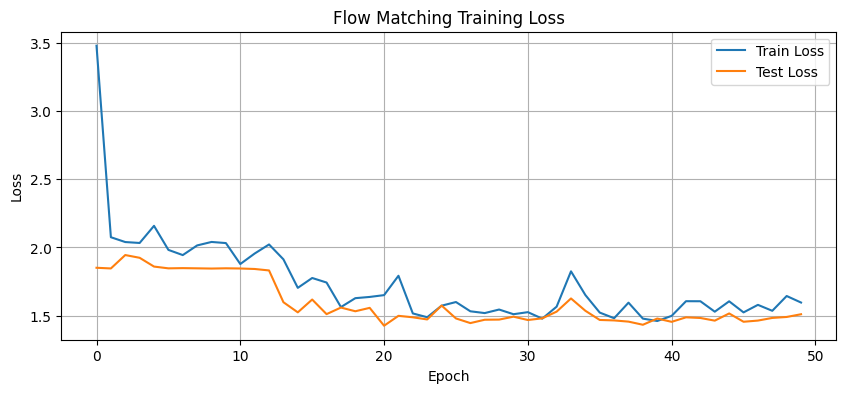

In [ ]:
DEMO_FM_EPOCHS = 50 

flow_trainer.train(train_loader, test_loader, num_epochs=DEMO_FM_EPOCHS)
flow_trainer.plot_loss()

## 3.5 Step 3: Flow Matching Sampling (ODE Solver)

Generate samples by solving the ODE:
$$\frac{dx}{dt} = v_\theta(x, t)$$

from $t=0$ (noise) to $t=1$ (data) using numerical integration.

In [ ]:
class FlowMatchingSampler:
    """
    ODE Sampler for Flow Matching.

    Solves the ODE: dx/dt = v_θ(x, t)
    from t=0 (Gaussian noise) to t=1 (data distribution)

    Available solvers:
    - Euler: Simple first-order method
    - Heun: Second-order Runge-Kutta
    - RK4: Fourth-order Runge-Kutta (more accurate)
    """
    def __init__(self, model, device):
        self.model = model
        self.device = device

    @torch.no_grad()
    def euler_step(self, x, t, dt):
        """Euler method: x_{t+dt} = x_t + v(x_t, t) * dt"""
        v = self.model(x, t)
        return x + v * dt

    @torch.no_grad()
    def heun_step(self, x, t, dt):
        """Heun's method (2nd order RK): Predictor-Corrector"""
        # Predictor (Euler step)
        v1 = self.model(x, t)
        x_pred = x + v1 * dt

        t_next = t + dt
        t_next = torch.clamp(t_next, 0, 1)
        v2 = self.model(x_pred, t_next)

        return x + (v1 + v2) * dt / 2

    @torch.no_grad()
    def rk4_step(self, x, t, dt):
        """Fourth-order Runge-Kutta (RK4)"""
        k1 = self.model(x, t)
        k2 = self.model(x + k1 * dt / 2, torch.clamp(t + dt / 2, 0, 1))
        k3 = self.model(x + k2 * dt / 2, torch.clamp(t + dt / 2, 0, 1))
        k4 = self.model(x + k3 * dt, torch.clamp(t + dt, 0, 1))

        return x + (k1 + 2*k2 + 2*k3 + k4) * dt / 6

    @torch.no_grad()
    def sample(self, n_samples, seq_len, feature_dim=1, n_steps=100, solver='euler', return_trajectory=False):
        """
        Generate samples using the trained vector field.

        Args:
            n_samples: Number of samples to generate
            seq_len: Sequence length
            feature_dim: Feature dimension
            n_steps: Number of ODE solver steps
            solver: 'euler', 'heun', or 'rk4'
            return_trajectory: Whether to return intermediate states

        Returns:
            Generated samples [n_samples, seq_len, feature_dim]
        """
        self.model.eval()

        x = torch.randn(n_samples, seq_len, feature_dim, device=self.device)

        dt = 1.0 / n_steps

        if solver == 'euler':
            step_fn = self.euler_step
        elif solver == 'heun':
            step_fn = self.heun_step
        elif solver == 'rk4':
            step_fn = self.rk4_step
        else:
            raise ValueError(f"Unknown solver: {solver}")

        trajectory = [x.clone()] if return_trajectory else None
        for i in range(n_steps):
            t_value = i / n_steps
            t_tensor = torch.full((n_samples,), t_value, device=self.device)
            x = step_fn(x, t_tensor, dt)
            if return_trajectory and i % (n_steps // 10) == 0:
                trajectory.append(x.clone())
        if return_trajectory:
            trajectory.append(x.clone())
            return x, trajectory

        return x

    def compare_solvers(self, n_samples=10, seq_len=64, n_steps_list=[10, 25, 50, 100, 200]):
        """
        Compare different solvers and step counts.

        Demonstrates effect of number of solver steps on generation quality
        and computational cost.
        """
        results = {}

        print("Comparing ODE solvers...")
        for solver in ['euler', 'heun', 'rk4']:
            for n_steps in n_steps_list:
                start_time = torch.cuda.Event(enable_timing=True) if self.device == 'cuda' else None
                end_time = torch.cuda.Event(enable_timing=True) if self.device == 'cuda' else None

                if start_time:
                    start_time.record()

                samples = self.sample(n_samples, seq_len, n_steps=n_steps, solver=solver)

                if end_time:
                    end_time.record()
                    torch.cuda.synchronize()
                    time_ms = start_time.elapsed_time(end_time)
                else:
                    time_ms = 0

                results[(solver, n_steps)] = {
                    'samples': samples,
                    'time_ms': time_ms,
                    'std': samples.std().item()
                }

                print(f"  {solver:5s} ({n_steps:3d} steps): std={samples.std().item():.4f}, time={time_ms:.1f}ms")

        return results




In [ ]:
flow_sampler = FlowMatchingSampler(flow_model, device)

for n_steps in [10, 50, 100]:
    samples = flow_sampler.sample(100, FM_CONFIG['seq_len'], n_steps=n_steps, solver='euler')
    print(f"Euler {n_steps:3d} steps: mean={samples.mean().item():.4f}, std={samples.std().item():.4f}")




📊 Comparing ODE Solver Effects:
--------------------------------------------------
Euler  10 steps: mean=0.0115, std=0.8388
Euler  50 steps: mean=-0.0082, std=0.9313
Euler 100 steps: mean=0.0009, std=0.9631


## 3.6 Steps 4-5: Visualizing Generated Time Series

Display generated samples and compare with real data.

In [ ]:
generated_samples = flow_sampler.sample(
    n_samples=500,
    seq_len=FM_CONFIG['seq_len'],
    n_steps=100,
    solver='euler'
)


In [ ]:

real_test_samples = torch.stack([test_dataset[i] for i in range(min(500, len(test_dataset)))])

print(f"Generated samples shape: {generated_samples.shape}")
print(f"Real samples shape: {real_test_samples.shape}")


def denormalize(data, mean, std):
    """Restore data to original scale."""
    return data * std + mean


In [ ]:


fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    sample_norm = generated_samples[i].squeeze().cpu().numpy()
    axes[0, i].plot(sample_norm, 'b-', alpha=0.8)
    axes[0, i].set_title(f'Generated Sample {i+1} (Normalized)')
    axes[0, i].set_xlabel('Time')
    axes[0, i].set_ylabel('Normalized Value')
    axes[0, i].grid(True, alpha=0.3)

for i in range(4):
    sample_denorm = denormalize(
        generated_samples[i].squeeze().cpu().numpy(),
        scaler_params['mean'],
        scaler_params['std']
    )
    axes[1, i].plot(sample_denorm, 'g-', alpha=0.8)
    axes[1, i].set_title(f'Generated Sample {i+1} (Denormalized)')
    axes[1, i].set_xlabel('Time')
    axes[1, i].set_ylabel('Log-Return')
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Step 4: Generated Time Series Samples')
plt.tight_layout()
save_fig('fm_generated_samples.png')
plt.show()

Generating samples for visualization...
Generated samples shape: torch.Size([500, 64, 1])
Real samples shape: torch.Size([290, 64, 1])
✅ Saved figure: ../report/En_report/figures/fm_generated_samples.png


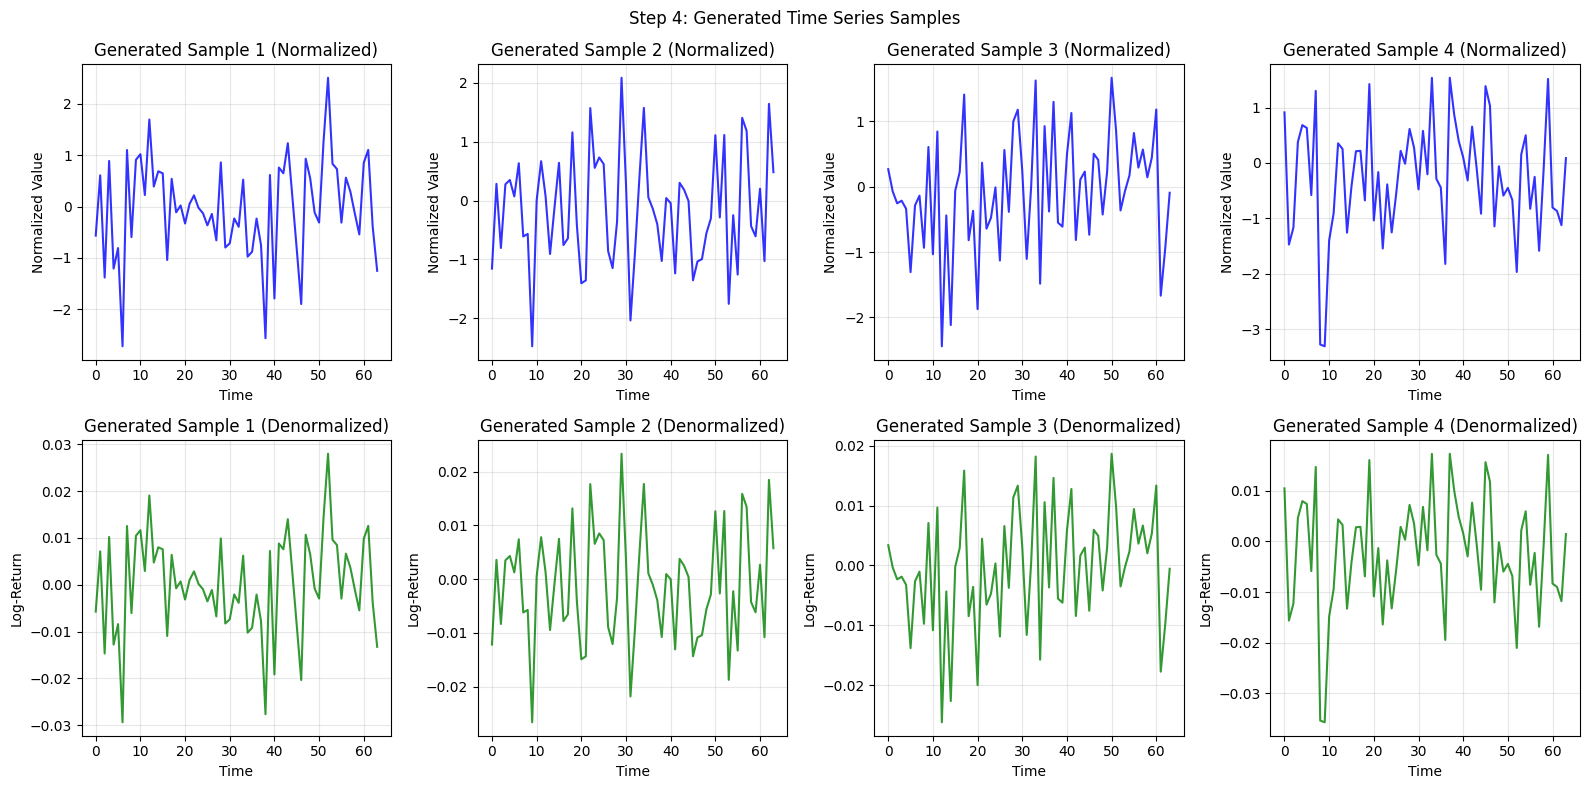

✅ Saved figure: ../report/En_report/figures/fm_real_vs_gen.png


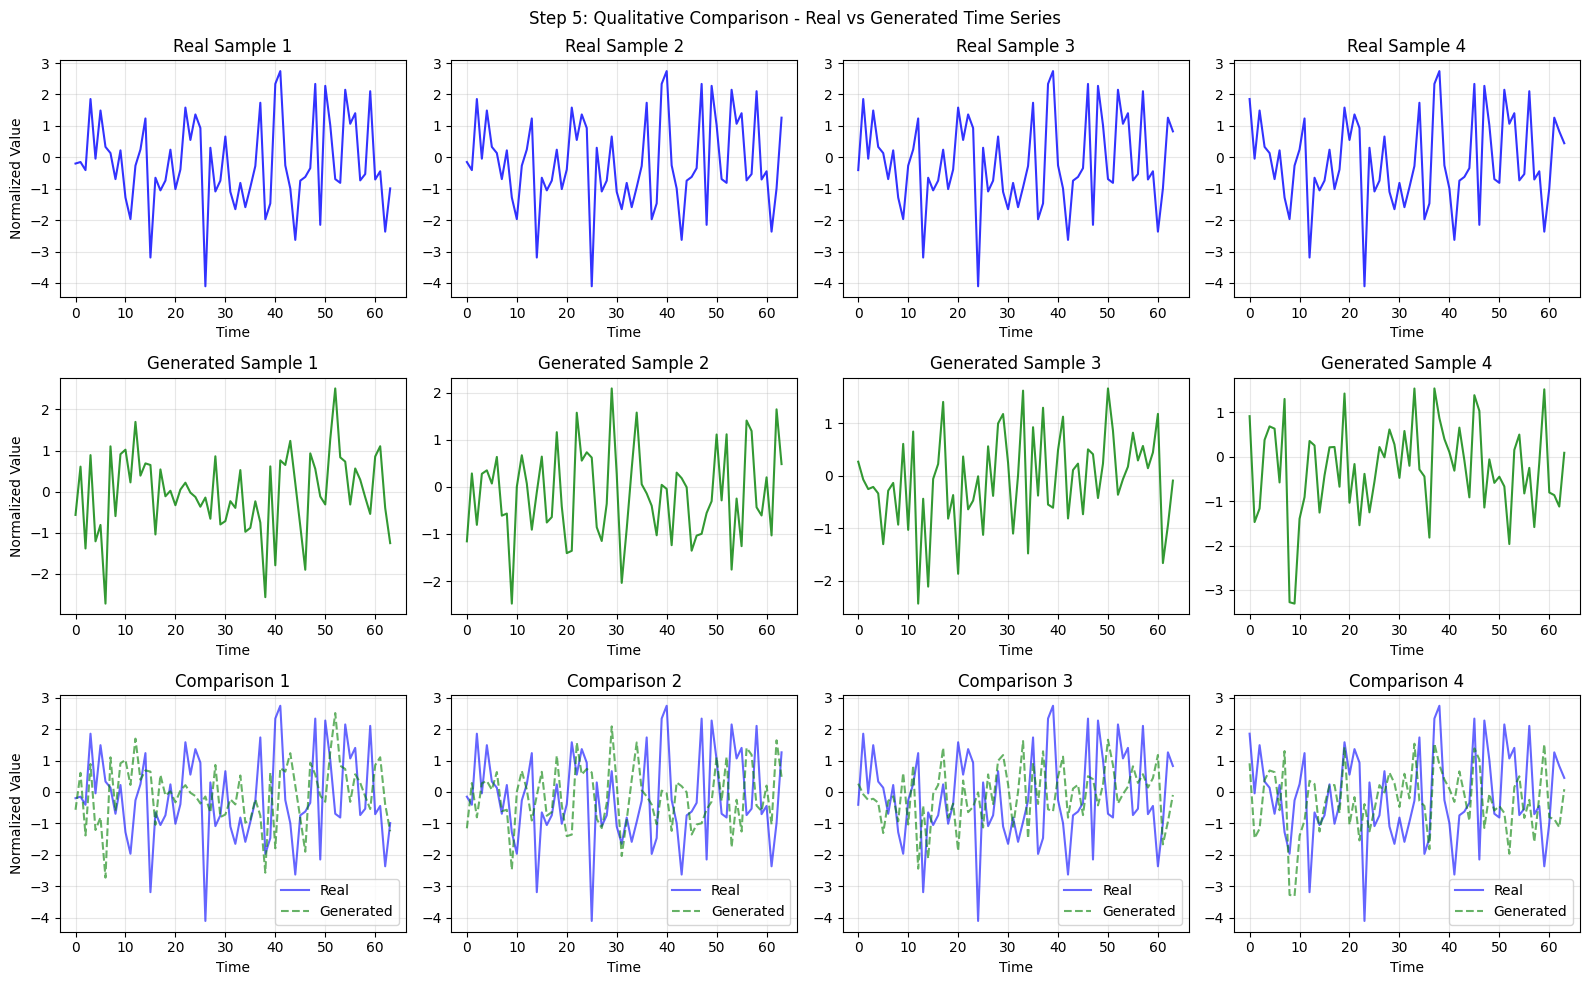

✅ Visualization complete!


In [ ]:



fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for i in range(4):
    sample = real_test_samples[i].squeeze().cpu().numpy()
    axes[0, i].plot(sample, 'b-', alpha=0.8)
    axes[0, i].set_title(f'Real Sample {i+1}')
    axes[0, i].set_xlabel('Time')
    axes[0, i].grid(True, alpha=0.3)
axes[0, 0].set_ylabel('Normalized Value')

for i in range(4):
    sample = generated_samples[i].squeeze().cpu().numpy()
    axes[1, i].plot(sample, 'g-', alpha=0.8)
    axes[1, i].set_title(f'Generated Sample {i+1}')
    axes[1, i].set_xlabel('Time')
    axes[1, i].grid(True, alpha=0.3)
axes[1, 0].set_ylabel('Normalized Value')

for i in range(4):
    real = real_test_samples[i].squeeze().cpu().numpy()
    gen = generated_samples[i].squeeze().cpu().numpy()
    axes[2, i].plot(real, 'b-', alpha=0.6, label='Real')
    axes[2, i].plot(gen, 'g--', alpha=0.6, label='Generated')
    axes[2, i].set_title(f'Comparison {i+1}')
    axes[2, i].set_xlabel('Time')
    axes[2, i].legend()
    axes[2, i].grid(True, alpha=0.3)
axes[2, 0].set_ylabel('Normalized Value')

plt.suptitle('Step 5: Qualitative Comparison - Real vs Generated Time Series')
plt.tight_layout()
save_fig('fm_real_vs_gen.png')
plt.show()



## 3.7 Step 6: Distribution Comparison (Histogram/KDE)

Compare the distribution of log-returns between real and generated data.

📊 Step 6: Comparing Distributions of Real and Generated Data
✅ Saved figure: ../report/En_report/figures/fm_dist_comparison.png


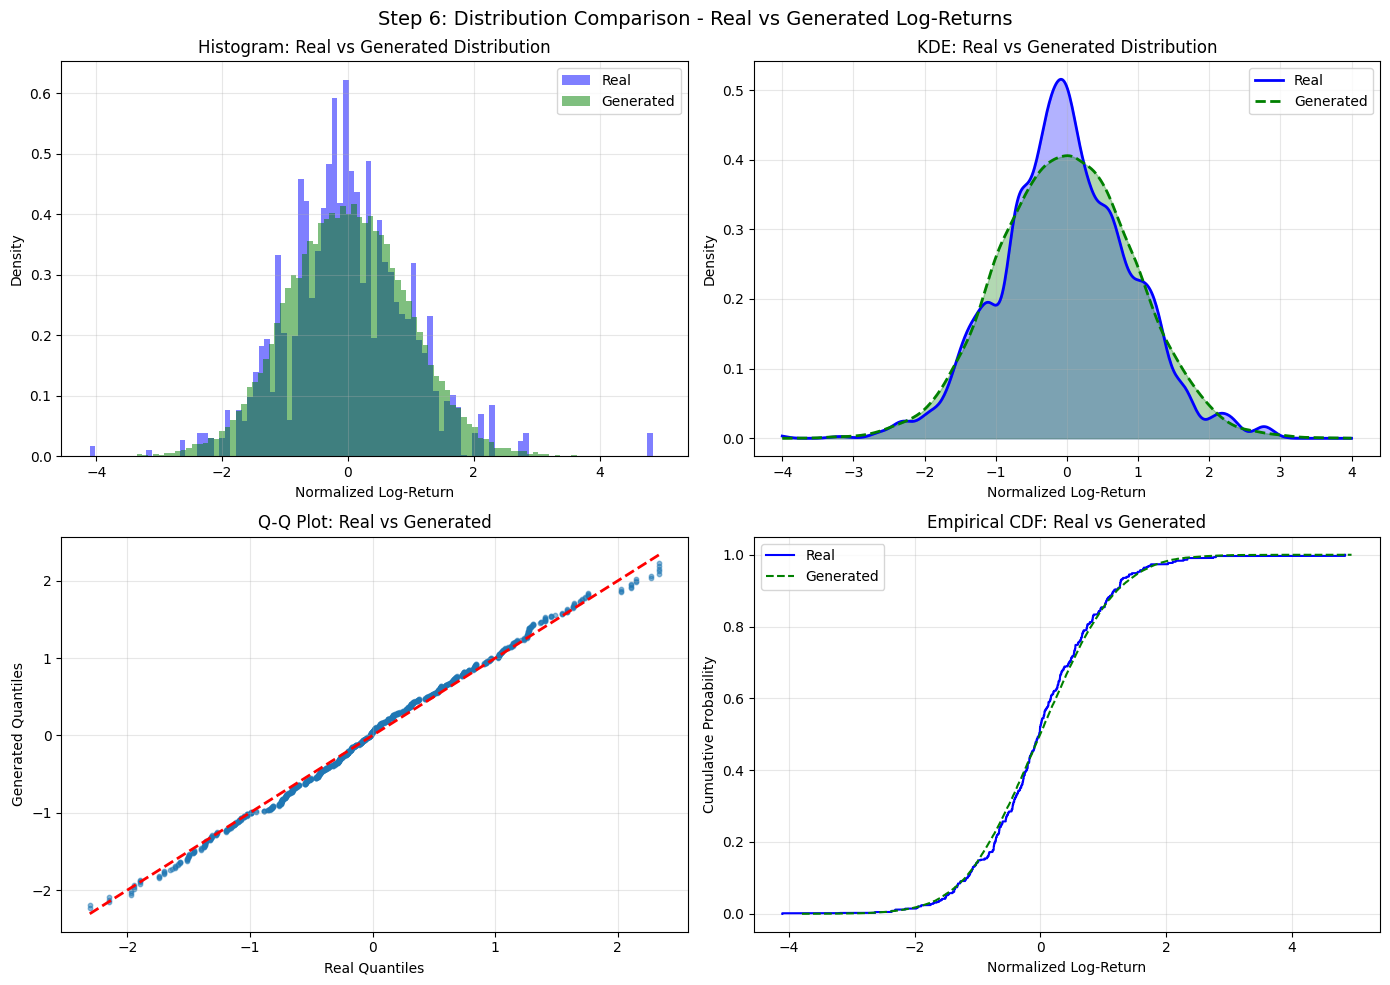


📊 Distribution Similarity Metrics:
  Kolmogorov-Smirnov Statistic: 0.0431
  KS p-value: 2.0152e-19
  Wasserstein Distance: 0.0628

  Interpretation:
  - Lower KS statistic = more similar distributions
  - Lower Wasserstein distance = closer distributions


In [ ]:
print("📊 Step 6: Comparing Distributions of Real and Generated Data")
print("=" * 60)

real_values = real_test_samples.squeeze().cpu().numpy().flatten()
gen_values = generated_samples.squeeze().cpu().numpy().flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.hist(real_values, bins=100, alpha=0.5, density=True, label='Real', color='blue')
ax1.hist(gen_values, bins=100, alpha=0.5, density=True, label='Generated', color='green')
ax1.set_xlabel('Normalized Log-Return')
ax1.set_ylabel('Density')
ax1.set_title('Histogram: Real vs Generated Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
from scipy.stats import gaussian_kde

real_kde = gaussian_kde(real_values)
gen_kde = gaussian_kde(gen_values)
x_range = np.linspace(-4, 4, 500)

ax2.plot(x_range, real_kde(x_range), 'b-', linewidth=2, label='Real')
ax2.plot(x_range, gen_kde(x_range), 'g--', linewidth=2, label='Generated')
ax2.fill_between(x_range, real_kde(x_range), alpha=0.3, color='blue')
ax2.fill_between(x_range, gen_kde(x_range), alpha=0.3, color='green')
ax2.set_xlabel('Normalized Log-Return')
ax2.set_ylabel('Density')
ax2.set_title('KDE: Real vs Generated Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
real_sorted = np.sort(real_values)
gen_sorted = np.sort(gen_values)

n_points = min(1000, len(real_sorted), len(gen_sorted))
real_quantiles = np.percentile(real_values, np.linspace(1, 99, n_points))
gen_quantiles = np.percentile(gen_values, np.linspace(1, 99, n_points))

ax3.scatter(real_quantiles, gen_quantiles, alpha=0.5, s=10)
ax3.plot([real_quantiles.min(), real_quantiles.max()],
         [real_quantiles.min(), real_quantiles.max()], 'r--', linewidth=2)
ax3.set_xlabel('Real Quantiles')
ax3.set_ylabel('Generated Quantiles')
ax3.set_title('Q-Q Plot: Real vs Generated')
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
real_ecdf = np.arange(1, len(real_values) + 1) / len(real_values)
gen_ecdf = np.arange(1, len(gen_values) + 1) / len(gen_values)

ax4.plot(np.sort(real_values), real_ecdf, 'b-', label='Real', linewidth=1.5)
ax4.plot(np.sort(gen_values), gen_ecdf, 'g--', label='Generated', linewidth=1.5)
ax4.set_xlabel('Normalized Log-Return')
ax4.set_ylabel('Cumulative Probability')
ax4.set_title('Empirical CDF: Real vs Generated')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Step 6: Distribution Comparison - Real vs Generated Log-Returns', fontsize=14)
plt.tight_layout()
save_fig('fm_dist_comparison.png')
plt.show()

from scipy.stats import ks_2samp, wasserstein_distance

ks_stat, ks_pvalue = ks_2samp(real_values, gen_values)
w_distance = wasserstein_distance(real_values, gen_values)

print(f"  Kolmogorov-Smirnov Statistic: {ks_stat:.4f}")
print(f"  KS p-value: {ks_pvalue:.4e}")
print(f"  Wasserstein Distance: {w_distance:.4f}")
print(f"\n  Interpretation:")
print(f"  - Lower KS statistic = more similar distributions")
print(f"  - Lower Wasserstein distance = closer distributions")

## 3.8 Step 7: Basic Statistical Evaluation and Volatility

Compare mean, variance, and volatility between real and generated data.

📊 Step 7: Basic Statistical Evaluation and Volatility

Real Data:
  Mean: 0.003770
  Variance: 0.927920
  Std (Volatility): 0.963286
  Avg Sequence Volatility: 0.912218
  Skewness: 0.3667
  Kurtosis: 2.2517

Generated Data:
  Mean: 0.000188
  Variance: 0.909990
  Std (Volatility): 0.953934
  Avg Sequence Volatility: 0.941377
  Skewness: 0.0344
  Kurtosis: 0.0784


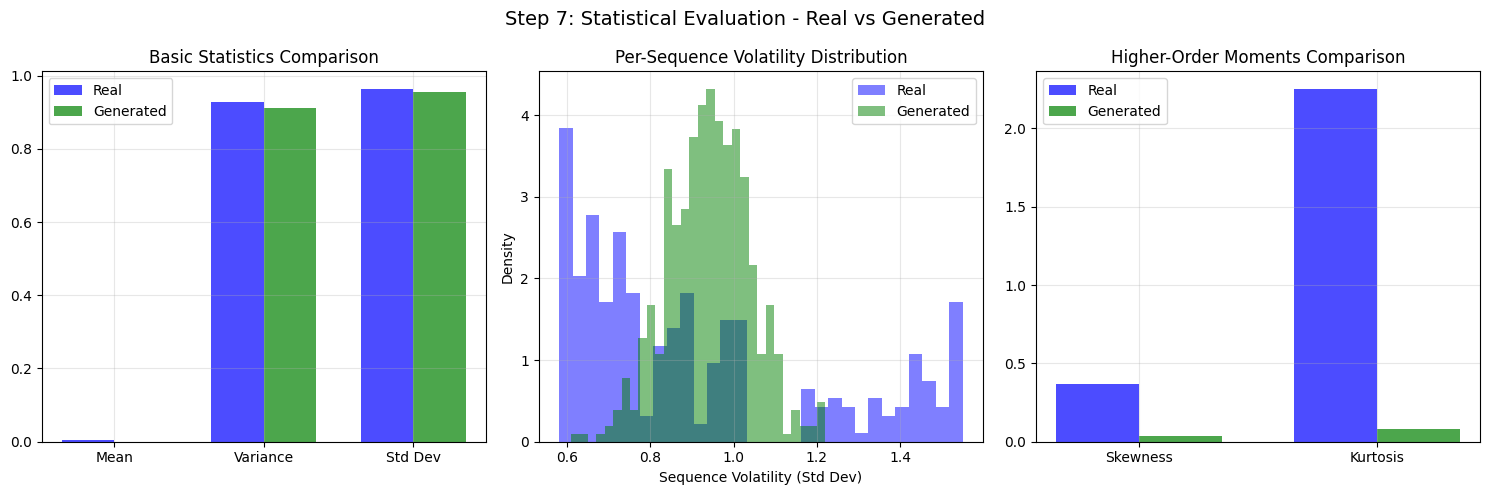


📊 Analysis:
  Mean Absolute Error: 0.003581
  Variance Relative Error: 1.9%
  Volatility Relative Error: 3.2%
  ✅ Model has correctly reproduced market volatility (error < 10%)


In [ ]:

def compute_statistics(data, name="Data"):
    values = data.squeeze().cpu().numpy() if torch.is_tensor(data) else data.squeeze()

    mean = np.mean(values)
    variance = np.var(values)
    std = np.std(values)
    skewness = stats.skew(values.flatten())
    kurtosis = stats.kurtosis(values.flatten())

    if len(values.shape) > 1:
        seq_volatilities = np.std(values, axis=1)
        avg_volatility = np.mean(seq_volatilities)
    else:
        avg_volatility = std

    print(f"\n{name}:")
    print(f"  Mean: {mean:.6f}")
    print(f"  Variance: {variance:.6f}")
    print(f"  Std (Volatility): {std:.6f}")
    print(f"  Avg Sequence Volatility: {avg_volatility:.6f}")
    print(f"  Skewness: {skewness:.4f}")
    print(f"  Kurtosis: {kurtosis:.4f}")

    return {
        'mean': mean,
        'variance': variance,
        'std': std,
        'volatility': avg_volatility,
        'skewness': skewness,
        'kurtosis': kurtosis
    }

real_stats = compute_statistics(real_test_samples, "Real Data")
gen_stats = compute_statistics(generated_samples, "Generated Data")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['mean', 'variance', 'std']
real_vals = [real_stats[m] for m in metrics]
gen_vals = [gen_stats[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, real_vals, width, label='Real', color='blue', alpha=0.7)
axes[0].bar(x + width/2, gen_vals, width, label='Generated', color='green', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Mean', 'Variance', 'Std Dev'])
axes[0].set_title('Basic Statistics Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

real_seq_vol = np.std(real_test_samples.squeeze().cpu().numpy(), axis=1)
gen_seq_vol = np.std(generated_samples.squeeze().cpu().numpy(), axis=1)

axes[1].hist(real_seq_vol, bins=30, alpha=0.5, density=True, label='Real', color='blue')
axes[1].hist(gen_seq_vol, bins=30, alpha=0.5, density=True, label='Generated', color='green')
axes[1].set_xlabel('Sequence Volatility (Std Dev)')
axes[1].set_ylabel('Density')
axes[1].set_title('Per-Sequence Volatility Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

moments = ['Skewness', 'Kurtosis']
real_moments = [real_stats['skewness'], real_stats['kurtosis']]
gen_moments = [gen_stats['skewness'], gen_stats['kurtosis']]

x = np.arange(len(moments))
axes[2].bar(x - width/2, real_moments, width, label='Real', color='blue', alpha=0.7)
axes[2].bar(x + width/2, gen_moments, width, label='Generated', color='green', alpha=0.7)
axes[2].set_xticks(x)
axes[2].set_xticklabels(moments)
axes[2].set_title('Higher-Order Moments Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)

plt.suptitle('Step 7: Statistical Evaluation - Real vs Generated', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📊 Analysis:")
mean_error = abs(real_stats['mean'] - gen_stats['mean'])
var_error = abs(real_stats['variance'] - gen_stats['variance']) / real_stats['variance'] * 100
vol_error = abs(real_stats['volatility'] - gen_stats['volatility']) / real_stats['volatility'] * 100

print(f"  Mean Absolute Error: {mean_error:.6f}")
print(f"  Variance Relative Error: {var_error:.1f}%")
print(f"  Volatility Relative Error: {vol_error:.1f}%")

if vol_error < 10:
    print("  ✅ Model has correctly reproduced market volatility (error < 10%)")
elif vol_error < 25:
    print("  ⚠️ Model approximately captures volatility (10% < error < 25%)")
else:
    print("  ❌ Model needs improvement in volatility reproduction (error > 25%)")

## 3.9 Step 8: Advanced Structural and Temporal Evaluation

Compute advanced metrics:
- **Sliced Wasserstein Distance (SWD)**: Measures distributional similarity
- **Autocorrelation**: Measures temporal dependencies
- **Autocorrelation MSE**: How well the model captures temporal structure

In [ ]:

def sliced_wasserstein_distance(X, Y, n_projections=100):
    """
    Compute Sliced Wasserstein Distance between two distributions.

    SWD approximates the Wasserstein distance by projecting data onto
    random 1D directions and computing the 1D Wasserstein distance.

    This metric is useful because:
    - It's computationally efficient
    - It captures both marginal and structural differences
    - It works well for high-dimensional data (like time series)
    """
    X = X.reshape(X.shape[0], -1)
    Y = Y.reshape(Y.shape[0], -1)

    dim = X.shape[1]

    projections = np.random.randn(n_projections, dim)
    projections = projections / np.linalg.norm(projections, axis=1, keepdims=True)

    X_proj = X @ projections.T 
    Y_proj = Y @ projections.T

    distances = []
    for i in range(n_projections):
        dist = wasserstein_distance(X_proj[:, i], Y_proj[:, i])
        distances.append(dist)

    return np.mean(distances)


def compute_autocorrelation(data, max_lag=20):
    """
    Compute autocorrelation for each sequence and average.

    Autocorrelation measures the correlation of a signal with
    a delayed copy of itself. It captures temporal dependencies.

    For financial data:
    - Positive AC at lag 1: momentum effect
    - Negative AC at lag 1: mean reversion
    - AC ≈ 0: efficient market (returns are roughly independent)
    """
    sequences = data.squeeze()
    if len(sequences.shape) == 1:
        sequences = sequences.reshape(1, -1)

    n_samples, seq_len = sequences.shape
    autocorrs = np.zeros((n_samples, max_lag))

    for i, seq in enumerate(sequences):
        seq = seq - np.mean(seq)
        var = np.var(seq)
        if var > 1e-10:
            for lag in range(1, max_lag + 1):
                if lag < seq_len:
                    autocorrs[i, lag-1] = np.corrcoef(seq[:-lag], seq[lag:])[0, 1]

    return np.mean(autocorrs, axis=0), autocorrs



In [ ]:
real_data_np = real_test_samples.squeeze().cpu().numpy()
gen_data_np = generated_samples.squeeze().cpu().numpy()


In [ ]:
swd = sliced_wasserstein_distance(real_data_np, gen_data_np)
print(f"   SWD: {swd:.4f}")

   SWD: 0.0985


In [89]:
real_ac_mean, real_ac_all = compute_autocorrelation(real_data_np)
gen_ac_mean, gen_ac_all = compute_autocorrelation(gen_data_np)


In [90]:
ac_mse = np.mean((real_ac_mean - gen_ac_mean) ** 2)
ac_mae = np.mean(np.abs(real_ac_mean - gen_ac_mean))

print(f"   Real AC(1): {real_ac_mean[0]:.4f}")
print(f"   Generated AC(1): {gen_ac_mean[0]:.4f}")
print(f"   Autocorrelation MSE: {ac_mse:.6f}")
print(f"   Autocorrelation MAE: {ac_mae:.6f}")
print(f"   Interpretation: Lower error = better temporal structure preservation")


   Real AC(1): 0.0273
   Generated AC(1): -0.0088
   Autocorrelation MSE: 0.003253
   Autocorrelation MAE: 0.047772
   Interpretation: Lower error = better temporal structure preservation


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
lags = np.arange(1, len(real_ac_mean) + 1)
ax1.bar(lags - 0.2, real_ac_mean, 0.4, label='Real', color='blue', alpha=0.7)
ax1.bar(lags + 0.2, gen_ac_mean, 0.4, label='Generated', color='green', alpha=0.7)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Lag')
ax1.set_ylabel('Autocorrelation')
ax1.set_title('Mean Autocorrelation by Lag')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ac_diff = gen_ac_mean - real_ac_mean
ax2.bar(lags, ac_diff, color=['red' if d < 0 else 'green' for d in ac_diff], alpha=0.7)
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Lag')
ax2.set_ylabel('Difference (Generated - Real)')
ax2.set_title('Autocorrelation Error by Lag')
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
ax3.hist(real_ac_all[:, 0], bins=30, alpha=0.5, density=True, label='Real', color='blue')
ax3.hist(gen_ac_all[:, 0], bins=30, alpha=0.5, density=True, label='Generated', color='green')
ax3.set_xlabel('AC(1) Value')
ax3.set_ylabel('Density')
ax3.set_title('Distribution of Lag-1 Autocorrelation')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
metrics = ['SWD', 'AC MSE', 'AC MAE']
values = [swd, ac_mse * 100, ac_mae * 100]  

bars = ax4.bar(metrics, values, color=['purple', 'orange', 'red'], alpha=0.7)
ax4.set_ylabel('Metric Value')
ax4.set_title('Summary of Evaluation Metrics')
ax4.grid(True, alpha=0.3)


✅ Saved figure: ../report/En_report/figures/fm_autocorr.png


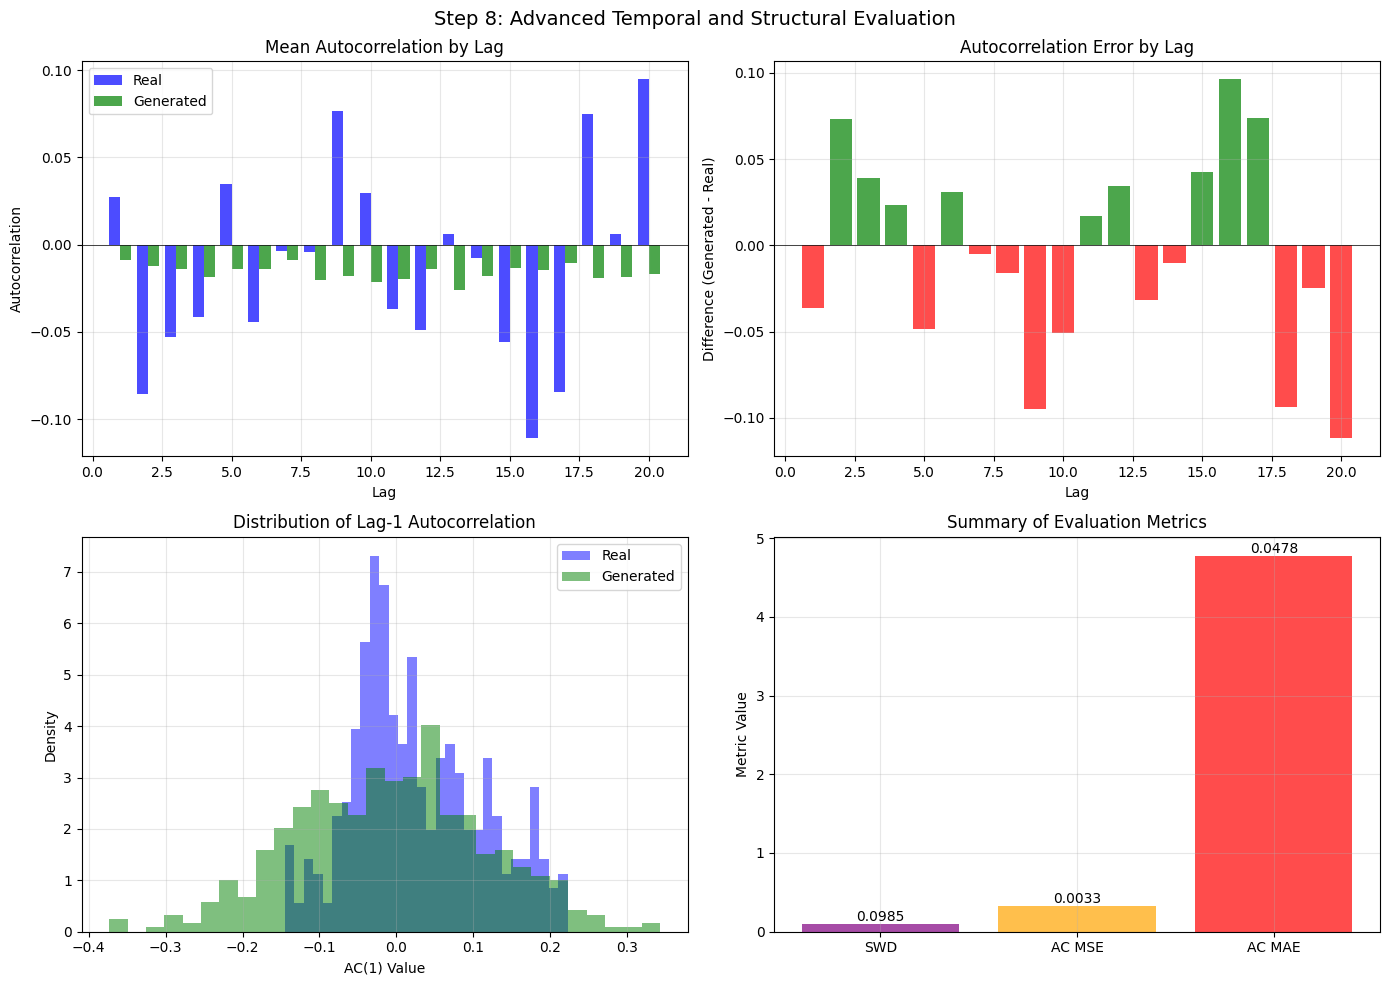

  Sliced Wasserstein Dist   0.0985          Lower = better
  Autocorrelation MSE       0.003253        Lower = better
  Autocorrelation MAE       0.047772        Lower = better

  What these metrics measure:
  - SWD: Overall distributional similarity including shape
  - AC MSE/MAE: How well temporal dependencies are preserved
  - If AC error is low, the model has learned temporal patterns

  ✅ Excellent temporal structure preservation!


In [ ]:

for bar, val in zip(bars, [swd, ac_mse, ac_mae]):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom')

plt.suptitle('Step 8: Advanced Temporal and Structural Evaluation', fontsize=14)
plt.tight_layout()
save_fig('fm_autocorr.png')
plt.show()

print(f"  {'Sliced Wasserstein Dist':<25} {swd:<15.4f} {'Lower = better'}")
print(f"  {'Autocorrelation MSE':<25} {ac_mse:<15.6f} {'Lower = better'}")
print(f"  {'Autocorrelation MAE':<25} {ac_mae:<15.6f} {'Lower = better'}")

print(f"\n  What these metrics measure:")
print(f"  - SWD: Overall distributional similarity including shape")
print(f"  - AC MSE/MAE: How well temporal dependencies are preserved")
print(f"  - If AC error is low, the model has learned temporal patterns")

if ac_mse < 0.01:
    print(f"\n  Excellent temporal structure preservation!")
elif ac_mse < 0.05:
    print(f"\n  Good but imperfect temporal structure preservation")
else:
    print(f"\n  Model needs improvement in temporal dependency learning")

## 3.10 Complete Evaluation Report

Final summary of all evaluation metrics and model performance.

In [ ]:
print(f"  Sequence Length: {FM_CONFIG['seq_len']}")
print(f"  Hidden Dimension: {FM_CONFIG['hidden_dim']}")
print(f"  Number of Layers: {FM_CONFIG['num_layers']}")
print(f"  Learning Rate: {FM_CONFIG['learning_rate']}")
print(f"  Batch Size: {FM_CONFIG['batch_size']}")
print(f"  Training Epochs: {DEMO_FM_EPOCHS}")

print(f"  Final Training Loss: {flow_trainer.train_loss_history[-1]:.5f}")
print(f"  Final Test Loss: {flow_trainer.test_loss_history[-1]:.5f}")
loss_gap = abs(flow_trainer.test_loss_history[-1] - flow_trainer.train_loss_history[-1])
print(f"  Train-Test Gap: {loss_gap:.5f}")

print(f"  {'Metric':<30} {'Real':<15} {'Generated':<15} {'Error'}")
print(f"  {'-'*70}")
print(f"  {'Mean':<30} {real_stats['mean']:<15.6f} {gen_stats['mean']:<15.6f} {abs(real_stats['mean']-gen_stats['mean']):.6f}")
print(f"  {'Variance':<30} {real_stats['variance']:<15.6f} {gen_stats['variance']:<15.6f} {abs(real_stats['variance']-gen_stats['variance']):.6f}")
print(f"  {'Std (Volatility)':<30} {real_stats['std']:<15.6f} {gen_stats['std']:<15.6f} {abs(real_stats['std']-gen_stats['std']):.6f}")
print(f"  {'Skewness':<30} {real_stats['skewness']:<15.4f} {gen_stats['skewness']:<15.4f} {abs(real_stats['skewness']-gen_stats['skewness']):.4f}")
print(f"  {'Kurtosis':<30} {real_stats['kurtosis']:<15.4f} {gen_stats['kurtosis']:<15.4f} {abs(real_stats['kurtosis']-gen_stats['kurtosis']):.4f}")

print(f"  Sliced Wasserstein Distance: {swd:.4f}")
print(f"  Wasserstein Distance (1D): {w_distance:.4f}")
print(f"  KS Statistic: {ks_stat:.4f}")

print(f"  Autocorrelation MSE: {ac_mse:.6f}")
print(f"  Autocorrelation MAE: {ac_mae:.6f}")
print(f"  Real AC(1): {real_ac_mean[0]:.4f}")
print(f"  Generated AC(1): {gen_ac_mean[0]:.4f}")


scores = {
    'Distribution': 100 * max(0, 1 - swd),
    'Volatility': 100 * max(0, 1 - abs(real_stats['std'] - gen_stats['std']) / real_stats['std']),
    'Temporal': 100 * max(0, 1 - ac_mse * 10),
    'Statistics': 100 * max(0, 1 - abs(real_stats['variance'] - gen_stats['variance']) / real_stats['variance'])
}

for metric, score in scores.items():
    bar = '█' * int(score / 5) + '░' * (20 - int(score / 5))
    print(f"  {metric:<15}: [{bar}] {score:.1f}%")

overall_score = np.mean(list(scores.values()))
print(f"\n  OVERALL SCORE: {overall_score:.1f}%")

if overall_score > 80:
    print("  Excellent model performance!")
elif overall_score > 60:
    print("  Good performance, room for improvement")
else:
    print("  Model needs more training or architecture tuning")
print("\n" + "=" * 70)
print("                          END OF REPORT")
print("=" * 70)

       FLOW MATCHING TIME SERIES GENERATION - EVALUATION REPORT

📋 MODEL CONFIGURATION
----------------------------------------------------------------------
  Sequence Length: 64
  Hidden Dimension: 256
  Number of Layers: 4
  Learning Rate: 0.0002
  Batch Size: 512
  Training Epochs: 50

📊 TRAINING RESULTS
----------------------------------------------------------------------
  Final Training Loss: 1.59688
  Final Test Loss: 1.51123
  Train-Test Gap: 0.08565

📊 STATISTICAL METRICS
----------------------------------------------------------------------
  Metric                         Real            Generated       Error
  ----------------------------------------------------------------------
  Mean                           0.003770        0.000188        0.003581
  Variance                       0.927920        0.909990        0.017931
  Std (Volatility)               0.963286        0.953934        0.009352
  Skewness                       0.3667          0.0344          0.3323
  K

---
# Summary and Conclusion

## Part 1: DDPM & DDIM
- Implemented linear variance scheduler
- Created `perturb_input` function using reparameterization trick
- Built complete U-Net architecture with attention
- Implemented both DDPM (stochastic) and DDIM (deterministic) sampling

## Part 2: Stable Diffusion & DreamBooth
- Created DreamBoothDataset class with prior preservation support
- Implemented class image generation for preventing catastrophic forgetting
- Built training loop with LoRA for efficient fine-tuning
- Created inference pipeline for generating images with trained model

## Part 3: Flow Matching for Time Series
- Loaded and preprocessed SPY log-returns data
- Implemented Vector Field networks (MLP and Transformer)
- Created Flow Matching training with linear interpolation paths
- Built ODE solvers (Euler, Heun, RK4) for sampling
- Comprehensive evaluation with:
  - Distribution comparison (Histogram, KDE, Q-Q plots)
  - Basic statistics (Mean, Variance, Volatility)
  - Advanced metrics (Sliced Wasserstein Distance, Autocorrelation)

---

In [ ]:
torch.save({
    'model_state_dict': flow_model.state_dict(),
    'optimizer_state_dict': flow_optimizer.state_dict(),
    'train_loss': flow_trainer.train_loss_history,
    'test_loss': flow_trainer.test_loss_history,
    'config': FM_CONFIG,
    'scaler_params': scaler_params,
}, results_folder + 'flow_matching_model.pt')
print(f"Flow Matching model saved to '{results_folder}flow_matching_model.pt'")


Saving trained models...
✅ Flow Matching model saved to '.flow_matching_model.pt'
DDPM model saved to '.ddpm_model.pt'

🎉 All implementations complete!


In [ ]:

if len(trainer.loss_history) > 0:
    torch.save({
        'model_state_dict': ddpm_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss_history': trainer.loss_history,
        'config': DDPM_CONFIG,
    }, results_folder + 'ddpm_model.pt')
    print(f"DDPM model saved to '{results_folder}ddpm_model.pt'")

print("\n🎉 All implementations complete!")

✅ Saved figure: ../report/En_report/figures/fm_training_loss.png


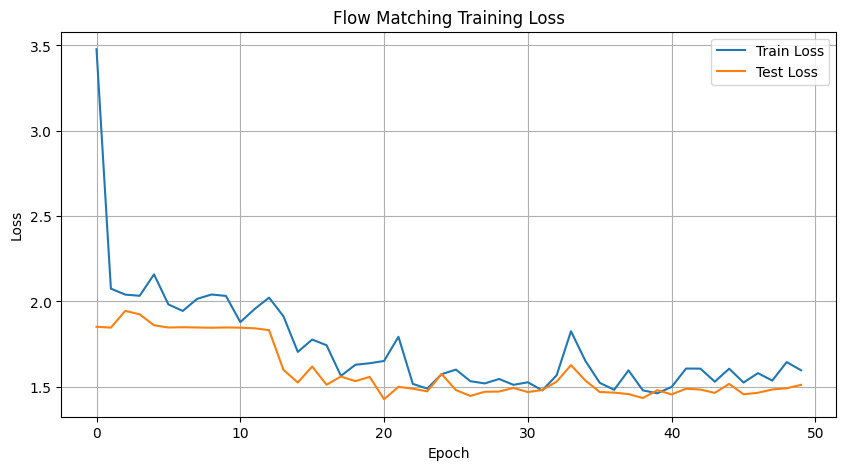

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(flow_trainer.train_loss_history, label='Train Loss')
plt.plot(flow_trainer.test_loss_history, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Flow Matching Training Loss')
plt.legend()
plt.grid(True)
save_fig('fm_training_loss.png')
plt.show()

## Next Steps & Tips
- Run a short end-to-end smoke test: 1 epoch, tiny dataset, check outputs.
- Save and version checkpoints frequently; keep the last 3 checkpoints to save space.
- Visual checks: generate a grid of samples after each epoch and inspect variety.
- Evaluation: compute FID/KID or simple perceptual metrics if applicable.
- Questions or issues: include shapes, exact error trace, and the cell number when asking for help.
